<div style="background:#0F1117; border-left: 6px solid #FF6B6B; padding: 28px 32px; border-radius:8px; font-family:'Segoe UI', sans-serif;">
<h1 style="color:#E8EAF0; margin:0 0 8px 0; font-size:2em;">
  🚗 Comparaison Technique — Produit A vs Produit V
</h1>
<p style="color:#7B7F99; font-size:1.05em; margin:0 0 18px 0;">
  Analyse complète de deux portefeuilles d'assurance automobile aux structures hétérogènes
</p>
<table style="border-collapse:collapse; width:100%; color:#E8EAF0;">
<tr style="background:#1A1D27;">
  <th style="padding:8px 14px; text-align:left; color:#7B7F99; font-weight:500;">Dimension</th>
  <th style="padding:8px 14px; color:#FF6B6B;">Produit A</th>
  <th style="padding:8px 14px; color:#4ECDC4;">Produit V</th>
</tr>
<tr><td style="padding:7px 14px;">Volume</td><td style="padding:7px 14px; color:#FF9F9F;">18 000 contrats</td><td style="padding:7px 14px; color:#A8E6E2;">14 000 contrats</td></tr>
<tr style="background:#1A1D27;"><td style="padding:7px 14px;">Âge conducteur</td><td style="padding:7px 14px; color:#FF9F9F;">Tranches (<code>18-25</code>, <code>26-35</code>, …)</td><td style="padding:7px 14px; color:#A8E6E2;">Valeur brute entière</td></tr>
<tr><td style="padding:7px 14px;">Carburant</td><td style="padding:7px 14px; color:#FF9F9F;">Libellés longs (Essence, Hybride…)</td><td style="padding:7px 14px; color:#A8E6E2;">Codes courts (E, D, HY, EL…)</td></tr>
<tr style="background:#1A1D27;"><td style="padding:7px 14px;">Garantie</td><td style="padding:7px 14px; color:#FF9F9F;">RC, DOMMAGES, VOL, BRIS_GLACE, ASSISTANCE</td><td style="padding:7px 14px; color:#A8E6E2;">RCO, DOM, VL, BG, ASS, PJ</td></tr>
<tr><td style="padding:7px 14px;">Usage</td><td style="padding:7px 14px; color:#FF9F9F;">Promenade, Tous Trajets, Pro, Tournées</td><td style="padding:7px 14px; color:#A8E6E2;">Perso, Mixte, Pro, Loisir, Service</td></tr>
<tr style="background:#1A1D27;"><td style="padding:7px 14px;">Géographie</td><td style="padding:7px 14px; color:#FF9F9F;">Région (6 modalités)</td><td style="padding:7px 14px; color:#A8E6E2;">Numéro de département</td></tr>
</table>
</div>

---

## Plan du notebook

| # | Section | Contenu |
|---|---------|---------|
| 1 | **Imports & Configuration** | Palette, style, constantes, helpers |
| 2 | **Génération des datasets** | Simulation réaliste des deux portefeuilles |
| 3 | **Mapping & Harmonisation** | Dictionnaires de correspondance, tranchage de l'âge |
| 4 | **Qualité des données** | Valeurs manquantes, doublons, distributions brutes |
| 5 | **KPIs Globaux** | Dashboard métriques, décomposition S/P |
| 6 | **Analyse par Garantie** | Deep-dive : fréquence, sévérité, S/P, prime, volume |
| 7 | **Analyse Univariée — Âge** | Distribution, relativités, concentration, KDE |
| 8 | **Analyse Univariée — Carburant** | Mapping avant/après, indices de risque |
| 9 | **Analyse Univariée — Usage & Ancienneté** | Profils sinistralité |
| 10 | **Analyse Univariée — Puissance** | Corrélation prime/risque |
| 11 | **Analyse Bivariée** | Heatmaps, scatter, boxplots croisés |
| 12 | **Cartographie du Risque** | Quadrant Fréquence × Sévérité (bubble chart) |
| 13 | **Concentration de la Charge** | Courbe de Lorenz des sinistres |
| 14 | **Profil de Rentabilité** | S/P par segment, waterfall, lollipop |
| 15 | **Synthèse Comparative** | Radar, table finale, conclusions |


## 1. Imports & Configuration

In [1]:
# ─── Bibliothèques ────────────────────────────────────────────────────────────
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.patches as mpatches
import matplotlib.gridspec as gridspec
from matplotlib.patches import FancyBboxPatch, FancyArrowPatch
from matplotlib.lines import Line2D
import matplotlib.patheffects as pe
import seaborn as sns
from scipy import stats
from scipy.stats import gaussian_kde
from itertools import product as iterproduct

pd.set_option("display.max_columns", 40)
pd.set_option("display.float_format", "{:.4f}".format)
np.random.seed(42)


In [2]:
# ─── Palette & thème ─────────────────────────────────────────────────────────

# Couleurs de base
BG      = "#0F1117"    # fond figure
PANEL   = "#1A1D27"    # fond axes
BORDER  = "#2E3147"    # bordures légères
GRID    = "#1F2233"    # grille
TEXT    = "#E8EAF0"    # texte principal
MUTED   = "#7B7F99"    # texte secondaire
ACCENT  = "#FFE66D"    # accent (seuils, annotations)
ACCENT2 = "#C084FC"    # second accent

# Produits
A_MAIN  = "#FF6B6B"    # coral  → Produit A
A_LIGHT = "#FF9F9F"
A_DARK  = "#CC3333"
V_MAIN  = "#4ECDC4"    # teal   → Produit V
V_LIGHT = "#A8E6E2"
V_DARK  = "#2A9D8F"

# Palettes catégorielles
PALETTE_GAR = {
    "RC":                   "#FF6B6B",
    "Dommages":             "#FF9F43",
    "Vol":                  "#FFE66D",
    "Bris de Glace":        "#4ECDC4",
    "Assistance":           "#A29BFE",
    "Protection Juridique": "#FD79A8",
}
PALETTE_CARB = {
    "Essence":              "#FF8C42",
    "Diesel":               "#6C8EBF",
    "Hybride/Electrique":   "#2ECC71",
    "Autres":               "#95A5A6",
}
PALETTE_USAGE = {
    "Personnel/Loisir": "#74B9FF",
    "Mixte":            "#FDCB6E",
    "Professionnel":    "#E17055",
}

# Style global matplotlib
plt.rcParams.update({
    # fond
    "figure.facecolor":    BG,
    "axes.facecolor":      PANEL,
    "axes.edgecolor":      BORDER,
    # texte
    "text.color":          TEXT,
    "axes.labelcolor":     TEXT,
    "axes.titlecolor":     TEXT,
    "axes.titlesize":      11,
    "axes.titleweight":    "bold",
    "axes.titlepad":       10,
    "axes.labelsize":      9,
    "xtick.color":         MUTED,
    "ytick.color":         MUTED,
    "xtick.labelsize":     8,
    "ytick.labelsize":     8,
    # grille
    "axes.grid":           True,
    "axes.axisbelow":      True,
    "grid.color":          GRID,
    "grid.linewidth":      0.6,
    "grid.linestyle":      "--",
    # spines
    "axes.spines.top":     False,
    "axes.spines.right":   False,
    "axes.spines.left":    False,
    "axes.spines.bottom":  False,
    # légende
    "legend.fontsize":     8,
    "legend.facecolor":    PANEL,
    "legend.edgecolor":    BORDER,
    "legend.labelcolor":   TEXT,
    "legend.framealpha":   0.9,
    # figure
    "figure.dpi":          120,
    "savefig.bbox":        "tight",
    "savefig.facecolor":   BG,
})

print("✓ Styles chargés")


✓ Styles chargés


In [3]:
# ─── Ordres canoniques ────────────────────────────────────────────────────────
AGE_ORDER   = ["18-25", "26-35", "36-45", "46-55", "56-65", "65+"]
CARB_ORDER  = ["Essence", "Diesel", "Hybride/Electrique", "Autres"]
USAGE_ORDER = ["Personnel/Loisir", "Mixte", "Professionnel"]
GAR_ORDER   = ["RC", "Dommages", "Vol", "Bris de Glace", "Assistance", "Protection Juridique"]
ANC_LABELS  = ["0-2", "2-5", "5-10", "10-15", "15-20", "20-30", "30+"]
ANC_BINS    = [0, 2, 5, 10, 15, 20, 30, 46]

# ─── Fonctions utilitaires ───────────────────────────────────────────────────

def fmt_pct(v: float, _=None) -> str:
    return f"{v:.1%}"

def fmt_eur(v: float, _=None) -> str:
    return f"{v/1000:.1f}k€" if v >= 1000 else f"{v:.0f}€"

def fmt_k(v: float, _=None) -> str:
    return f"{v/1000:.0f}k" if v >= 1000 else str(int(v))

def annotate_bars(ax, bars, fmt="{:.0f}", offset_frac=0.015,
                  color=TEXT, fontsize=7, fontweight="bold", rotate=False):
    """Ajoute les valeurs au-dessus de chaque barre d'un bar chart."""
    ymax = ax.get_ylim()[1]
    offset = ymax * offset_frac
    for bar in bars:
        h = bar.get_height()
        if h == 0 or np.isnan(h):
            continue
        label = fmt.format(h)
        kw = dict(ha="center", va="bottom", color=color,
                  fontsize=fontsize, fontweight=fontweight)
        if rotate:
            kw.update(rotation=45, ha="left")
        ax.text(bar.get_x() + bar.get_width() / 2,
                h + offset, label, **kw)

def add_seuil_line(ax, y=1.0, label="S/P = 100 %", color=ACCENT):
    """Trace une ligne de référence horizontale."""
    ax.axhline(y, color=color, linestyle="--", linewidth=1.3,
               zorder=3, alpha=0.85)
    ax.text(ax.get_xlim()[1], y, f"  {label}",
            color=color, va="center", fontsize=7.5, fontweight="bold")

def style_colorbar(cb, label=""):
    cb.set_label(label, color=MUTED, fontsize=8)
    cb.ax.yaxis.set_tick_params(color=MUTED)
    plt.setp(cb.ax.yaxis.get_ticklabels(), color=MUTED, fontsize=7)

print("✓ Helpers chargés")


✓ Helpers chargés


## 2. Génération des Datasets Synthétiques

In [4]:
def make_dataset_A(n: int = 18_000) -> pd.DataFrame:
    """
    Simule le portefeuille Produit A.

    Spécificités structurelles :
    - age_tranche      : variable catégorielle encodée en tranches à la source
    - carburant        : libellés longs
    - garantie         : codes internes (RC, DOMMAGES, VOL, BRIS_GLACE, ASSISTANCE)
    - usage            : libellés métier (Promenade, Tous Trajets, …)
    - region           : 6 grandes régions
    - puissance_fiscale: puissance fiscale (CV)
    - anciennete_permis: années depuis l'obtention du permis

    Modèle de tarification :
        prime = base_garantie × bruit × malus_jeune × bonus_vert

    Modèle de sinistralité :
        nb_sinistres ~ Poisson(λ × malus_jeune)
        charge       ~ Γ(shape=2, scale=sev/2) × nb_sinistres
    """
    rng = np.random.default_rng(42)

    garantie = rng.choice(
        ["RC", "DOMMAGES", "VOL", "BRIS_GLACE", "ASSISTANCE"],
        n, p=[0.30, 0.28, 0.15, 0.17, 0.10]
    )
    carburant = rng.choice(
        ["Essence", "Diesel", "Hybride", "GPL", "Electrique"],
        n, p=[0.38, 0.35, 0.14, 0.06, 0.07]
    )
    age_tranche = rng.choice(
        ["18-25", "26-35", "36-45", "46-55", "56-65", "65+"],
        n, p=[0.10, 0.22, 0.25, 0.22, 0.14, 0.07]
    )
    usage = rng.choice(
        ["Promenade", "Tous Trajets", "Professionnel", "Tournées"],
        n, p=[0.40, 0.35, 0.18, 0.07]
    )
    region = rng.choice(
        ["IDF", "Sud-Est", "Ouest", "Nord", "Est", "Sud-Ouest"],
        n, p=[0.28, 0.18, 0.15, 0.16, 0.13, 0.10]
    )
    anciennete    = np.clip(rng.gamma(4, 5, n).astype(int), 0, 45)
    puissance_fis = rng.choice(
        range(4, 16), n,
        p=[0.04, 0.10, 0.17, 0.22, 0.17, 0.12, 0.07, 0.04, 0.03, 0.02, 0.01, 0.01]
    )

    # ── Primes ───────────────────────────────────────────────────────────────
    prime_base = {"RC": 280, "DOMMAGES": 450, "VOL": 180, "BRIS_GLACE": 90, "ASSISTANCE": 60}
    prime_vec  = np.array([prime_base[g] for g in garantie], dtype=float)

    mult_young = np.where(age_tranche == "18-25", 1.40, 1.0)
    mult_senior= np.where(age_tranche == "65+",   0.92, 1.0)
    mult_carb  = np.where(carburant == "Electrique", 0.85,
                 np.where(carburant == "Hybride",    0.92,
                 np.where(carburant == "GPL",        0.97, 1.0)))
    mult_usage = np.where(usage == "Professionnel", 1.18,
                 np.where(usage == "Tournées",      1.12, 1.0))
    mult_pw    = 1 + (puissance_fis - 8) * 0.018   # relativité puissance

    prime_acquise = np.clip(
        prime_vec
        * rng.normal(1, 0.10, n)
        * mult_young * mult_senior * mult_carb * mult_usage * mult_pw,
        25, 3000
    ).round(2)

    # ── Sinistres ─────────────────────────────────────────────────────────────
    freq_base = {"RC": 0.060, "DOMMAGES": 0.090, "VOL": 0.040,
                 "BRIS_GLACE": 0.100, "ASSISTANCE": 0.155}
    freq_vec   = np.array([freq_base[g] for g in garantie], dtype=float)
    freq_vec  *= np.where(age_tranche == "18-25", 1.45, 1.0)
    freq_vec  *= np.where(age_tranche == "65+",   0.88, 1.0)
    freq_vec  *= np.where(usage == "Professionnel", 1.20, 1.0)
    nb_sin     = rng.poisson(freq_vec).astype(int)

    sev_base = {"RC": 4_500, "DOMMAGES": 6_800, "VOL": 8_200,
                "BRIS_GLACE": 320, "ASSISTANCE": 185}
    charge = np.where(
        nb_sin > 0,
        [rng.gamma(2, sev_base[g] / 2) * max(nb_sin[i], 1)
         for i, g in enumerate(garantie)],
        0.0
    ).round(2)

    return pd.DataFrame({
        "police_id":          [f"A{i:06d}" for i in range(n)],
        "garantie":           garantie,
        "age_tranche":        age_tranche,
        "carburant":          carburant,
        "usage":              usage,
        "region":             region,
        "anciennete_permis":  anciennete,
        "puissance_fiscale":  puissance_fis,
        "prime_acquise":      prime_acquise,
        "nb_sinistres":       nb_sin,
        "charge_sinistre":    charge,
    })


In [5]:
def make_dataset_V(n: int = 14_000) -> pd.DataFrame:
    """
    Simule le portefeuille Produit V.

    Spécificités structurelles :
    - age_conducteur : valeur brute entière (18-80), PAS de tranches
    - energie        : codes ISO courts (E, D, HY, EL, GN, AU)
    - couverture     : codes produit internes différents de A
    - utilisation    : libellés différents de A
    - departement    : numéro (int), pas de région nommée
    - puissance_din  : puissance DIN (ch), différente de la fiscale
    - annees_permis  : dérivé de l'âge
    """
    rng = np.random.default_rng(99)

    couverture = rng.choice(
        ["RCO", "DOM", "VL", "BG", "ASS", "PJ"],
        n, p=[0.28, 0.26, 0.14, 0.16, 0.09, 0.07]
    )
    energie = rng.choice(
        ["E", "D", "HY", "EL", "GN", "AU"],
        n, p=[0.34, 0.30, 0.16, 0.10, 0.04, 0.06]
    )
    age_cond = np.clip(
        np.round(rng.beta(3, 2.5, n) * 55 + 18).astype(int), 18, 80
    )
    utilisation = rng.choice(
        ["Perso", "Mixte", "Pro", "Loisir", "Service"],
        n, p=[0.38, 0.28, 0.20, 0.08, 0.06]
    )
    departement   = rng.integers(1, 96, n)
    annees_permis = np.clip(age_cond - 18 - rng.integers(0, 3, n), 0, 60)
    puissance_din = rng.choice(range(50, 260, 5), n)

    # ── Primes ───────────────────────────────────────────────────────────────
    prime_base = {"RCO": 260, "DOM": 420, "VL": 190, "BG": 95, "ASS": 55, "PJ": 45}
    prime_vec  = np.array([prime_base[g] for g in couverture], dtype=float)

    mult_young  = np.where(age_cond < 26, 1.35, 1.0)
    mult_senior = np.where(age_cond >= 65, 0.90, 1.0)
    mult_el     = np.where(energie == "EL", 0.82,
                  np.where(energie == "HY", 0.90, 1.0))
    mult_pro    = np.where(np.isin(utilisation, ["Pro", "Service"]), 1.15, 1.0)
    mult_pw     = 1 + (puissance_din - 110) * 0.0010

    cotisation = np.clip(
        prime_vec
        * rng.normal(1, 0.12, n)
        * mult_young * mult_senior * mult_el * mult_pro * mult_pw,
        20, 2500
    ).round(2)

    # ── Sinistres ─────────────────────────────────────────────────────────────
    freq_base = {"RCO": 0.055, "DOM": 0.085, "VL": 0.042,
                 "BG":  0.095, "ASS": 0.140, "PJ": 0.068}
    freq_vec   = np.array([freq_base[g] for g in couverture], dtype=float)
    freq_vec  *= np.where(age_cond < 26,  1.38, 1.0)
    freq_vec  *= np.where(age_cond >= 65, 0.90, 1.0)
    freq_vec  *= np.where(np.isin(utilisation, ["Pro", "Service"]), 1.18, 1.0)
    nb_sin     = rng.poisson(freq_vec).astype(int)

    sev_base = {"RCO": 4_800, "DOM": 7_100, "VL": 8_500,
                "BG": 305,  "ASS": 175, "PJ": 660}
    charge = np.where(
        nb_sin > 0,
        [rng.gamma(2, sev_base[g] / 2) * max(nb_sin[i], 1)
         for i, g in enumerate(couverture)],
        0.0
    ).round(2)

    return pd.DataFrame({
        "contrat_id":       [f"V{i:06d}" for i in range(n)],
        "couverture":       couverture,
        "age_conducteur":   age_cond,
        "energie":          energie,
        "utilisation":      utilisation,
        "departement":      departement,
        "annees_permis":    annees_permis,
        "puissance_din":    puissance_din,
        "cotisation":       cotisation,
        "nb_sinistres":     nb_sin,
        "charge_sinistre":  charge,
    })


In [6]:
df_A = make_dataset_A(18_000)
df_V = make_dataset_V(14_000)

print(f"Produit A — {len(df_A):,} lignes × {df_A.shape[1]} colonnes")
print(f"  Colonnes : {list(df_A.columns)}\n")
print(f"Produit V — {len(df_V):,} lignes × {df_V.shape[1]} colonnes")
print(f"  Colonnes : {list(df_V.columns)}")


Produit A — 18,000 lignes × 11 colonnes
  Colonnes : ['police_id', 'garantie', 'age_tranche', 'carburant', 'usage', 'region', 'anciennete_permis', 'puissance_fiscale', 'prime_acquise', 'nb_sinistres', 'charge_sinistre']

Produit V — 14,000 lignes × 11 colonnes
  Colonnes : ['contrat_id', 'couverture', 'age_conducteur', 'energie', 'utilisation', 'departement', 'annees_permis', 'puissance_din', 'cotisation', 'nb_sinistres', 'charge_sinistre']


In [7]:
df_A.head()


,police_id,garantie,age_tranche,carburant,usage,region,anciennete_permis,puissance_fiscale,prime_acquise,nb_sinistres,charge_sinistre
0,A000000,BRIS_GLACE,56-65,Essence,Promenade,Ouest,12,6,90.1000,0,0.0000
1,A000001,DOMMAGES,26-35,Hybride,Tous Trajets,IDF,9,6,365.5300,0,0.0000
2,A000002,BRIS_GLACE,36-45,Electrique,Promenade,Nord,5,5,69.7600,0,0.0000
3,A000003,VOL,18-25,Essence,Promenade,IDF,25,6,198.3800,0,0.0000
4,A000004,RC,36-45,Hybride,Tous Trajets,IDF,12,7,279.5600,0,0.0000


In [8]:
df_V.head()


,contrat_id,couverture,age_conducteur,energie,utilisation,departement,annees_permis,puissance_din,cotisation,nb_sinistres,charge_sinistre
0,V000000,DOM,33,D,Perso,44,15,130,424.8000,0,0.0000
1,V000001,VL,28,GN,Service,90,9,250,238.3700,1,5500.1200
2,V000002,DOM,45,E,Perso,58,25,255,501.2700,0,0.0000
3,V000003,PJ,50,E,Perso,25,32,145,38.9800,0,0.0000
4,V000004,VL,52,D,Perso,52,32,135,133.9300,0,0.0000


## 3. Mapping & Harmonisation des Variables

In [9]:
# ─── Dictionnaires de correspondance ─────────────────────────────────────────
#
#   Convention : les valeurs non présentes dans le dictionnaire
#   sont renvoyées vers la catégorie "Autres" via .fillna()

MAP_CARB_A: dict[str, str] = {
    "Essence":    "Essence",
    "Diesel":     "Diesel",
    "Hybride":    "Hybride/Electrique",
    "Electrique": "Hybride/Electrique",
    "GPL":        "Autres",
}

MAP_CARB_V: dict[str, str] = {
    "E":  "Essence",
    "D":  "Diesel",
    "HY": "Hybride/Electrique",
    "EL": "Hybride/Electrique",
    "GN": "Autres",   # GNV
    "AU": "Autres",   # autre motorisation
}

MAP_USAGE_A: dict[str, str] = {
    "Promenade":     "Personnel/Loisir",
    "Tous Trajets":  "Mixte",
    "Professionnel": "Professionnel",
    "Tournées":      "Professionnel",
}

MAP_USAGE_V: dict[str, str] = {
    "Perso":   "Personnel/Loisir",
    "Loisir":  "Personnel/Loisir",
    "Mixte":   "Mixte",
    "Pro":     "Professionnel",
    "Service": "Professionnel",
}

MAP_GAR_A: dict[str, str] = {
    "RC":         "RC",
    "DOMMAGES":   "Dommages",
    "VOL":        "Vol",
    "BRIS_GLACE": "Bris de Glace",
    "ASSISTANCE": "Assistance",
}

MAP_GAR_V: dict[str, str] = {
    "RCO": "RC",
    "DOM": "Dommages",
    "VL":  "Vol",
    "BG":  "Bris de Glace",
    "ASS": "Assistance",
    "PJ":  "Protection Juridique",
}


def age_to_tranche(age_series: pd.Series) -> pd.Series:
    """Convertit une série d'âges entiers en tranches harmonisées."""
    return pd.cut(
        age_series,
        bins  = [0, 25, 35, 45, 55, 65, 200],
        labels= AGE_ORDER,
        right = True,
    ).astype(str)


# ─── Application ──────────────────────────────────────────────────────────────
df_A["carburant_h"]   = df_A["carburant"].map(MAP_CARB_A).fillna("Autres")
df_A["usage_h"]       = df_A["usage"].map(MAP_USAGE_A).fillna("Autres")
df_A["garantie_h"]    = df_A["garantie"].map(MAP_GAR_A).fillna("Autres")
df_A["age_tranche_h"] = df_A["age_tranche"]           # déjà en tranches
df_A["prime"]         = df_A["prime_acquise"]
df_A["produit"]       = "Produit A"

df_V["carburant_h"]   = df_V["energie"].map(MAP_CARB_V).fillna("Autres")
df_V["usage_h"]       = df_V["utilisation"].map(MAP_USAGE_V).fillna("Autres")
df_V["garantie_h"]    = df_V["couverture"].map(MAP_GAR_V).fillna("Autres")
df_V["age_tranche_h"] = age_to_tranche(df_V["age_conducteur"])
df_V["prime"]         = df_V["cotisation"]
df_V["produit"]       = "Produit V"

# Binning ancienneté permis (commun aux deux)
df_A["anc_bin"] = pd.cut(df_A["anciennete_permis"], bins=ANC_BINS, labels=ANC_LABELS)
df_V["anc_bin"] = pd.cut(df_V["annees_permis"],     bins=ANC_BINS, labels=ANC_LABELS)

print("Valeurs nulles après mapping")
print("-" * 40)
cols_h = ["carburant_h", "usage_h", "garantie_h", "age_tranche_h", "prime", "anc_bin"]
null_check = pd.concat(
    [df_A[cols_h].isnull().sum().rename("Produit A"),
     df_V[cols_h].isnull().sum().rename("Produit V")], axis=1
)
print(null_check)


Valeurs nulles après mapping
----------------------------------------
               Produit A  Produit V
carburant_h            0          0
usage_h                0          0
garantie_h             0          0
age_tranche_h          0          0
prime                  0          0
anc_bin                0        612


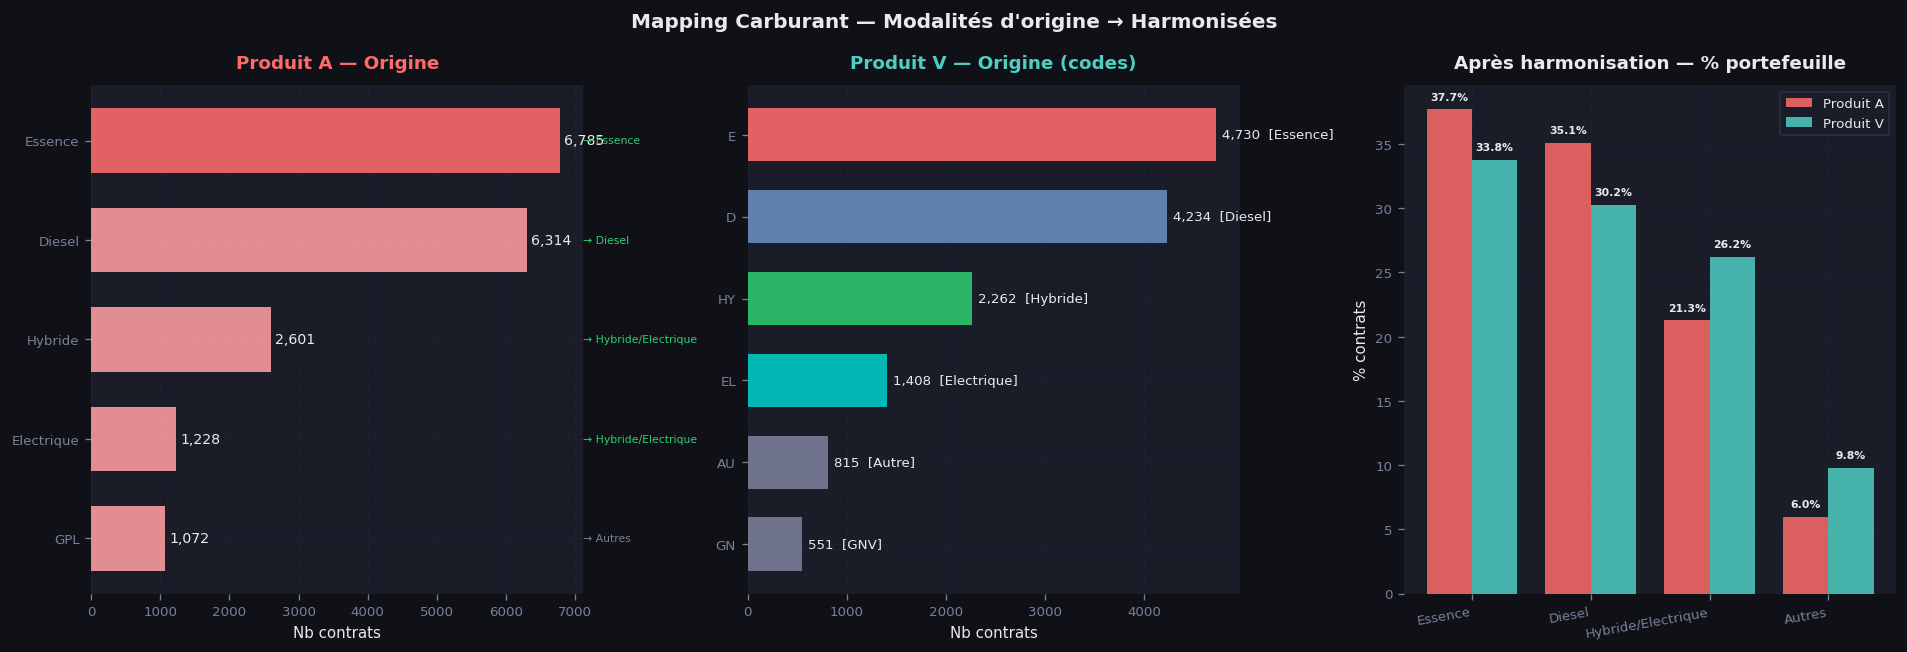

In [10]:
# ── Visualisation du mapping carburant ───────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 5.5))
fig.suptitle("Mapping Carburant — Modalités d'origine → Harmonisées", fontsize=12, fontweight="bold")

# Modalités brutes A
cnt_ba = df_A["carburant"].value_counts().sort_values()
colors_a = [A_MAIN if v == cnt_ba.max() else A_LIGHT for v in cnt_ba]
bars = axes[0].barh(cnt_ba.index, cnt_ba.values, color=colors_a, alpha=0.88, height=0.65)
axes[0].set_title("Produit A — Origine", color=A_MAIN)
axes[0].set_xlabel("Nb contrats")
for bar in bars:
    axes[0].text(bar.get_width() + 60, bar.get_y() + bar.get_height() / 2,
                 f"{bar.get_width():,.0f}", va="center", fontsize=8.5, color=TEXT)
# Annotation flèches de mapping
mapping_annot = {"Essence": "Essence", "Diesel": "Diesel",
                 "Hybride": "Hybride/Electrique", "Electrique": "Hybride/Electrique",
                 "GPL": "Autres"}
for i, (k, v) in enumerate(mapping_annot.items()):
    c = "#2ECC71" if v != "Autres" else MUTED
    axes[0].annotate(f"→ {v}", xy=(0, 0), fontsize=6.5, color=c,
                     xytext=(cnt_ba.max() * 1.05, cnt_ba.index.tolist().index(k)),
                     va="center")

# Modalités brutes V
cnt_bv = df_V["energie"].value_counts().sort_values()
map_color = {"E": A_MAIN, "D": "#6C8EBF", "HY": "#2ECC71",
             "EL": "#00CEC9", "GN": MUTED, "AU": MUTED}
colors_v = [map_color.get(c, V_MAIN) for c in cnt_bv.index]
bars_v = axes[1].barh(cnt_bv.index, cnt_bv.values, color=colors_v, alpha=0.88, height=0.65)
axes[1].set_title("Produit V — Origine (codes)", color=V_MAIN)
axes[1].set_xlabel("Nb contrats")
decodes = {"E": "Essence", "D": "Diesel", "HY": "Hybride",
           "EL": "Electrique", "GN": "GNV", "AU": "Autre"}
for bar, code in zip(bars_v, cnt_bv.index):
    axes[1].text(bar.get_width() + 60, bar.get_y() + bar.get_height() / 2,
                 f"{bar.get_width():,.0f}  [{decodes[code]}]",
                 va="center", fontsize=8, color=TEXT)

# Résultat harmonisé — proportions
h_a = df_A["carburant_h"].value_counts().reindex(CARB_ORDER).fillna(0) / len(df_A) * 100
h_v = df_V["carburant_h"].value_counts().reindex(CARB_ORDER).fillna(0) / len(df_V) * 100
x = np.arange(len(CARB_ORDER)); w = 0.38
b_a = axes[2].bar(x - w / 2, h_a, w, color=A_MAIN, alpha=0.85, label="Produit A")
b_v = axes[2].bar(x + w / 2, h_v, w, color=V_MAIN, alpha=0.85, label="Produit V")
axes[2].set_title("Après harmonisation — % portefeuille")
axes[2].set_xticks(x)
axes[2].set_xticklabels(CARB_ORDER, rotation=10, ha="right")
axes[2].set_ylabel("% contrats")
axes[2].legend()
annotate_bars(axes[2], b_a, fmt="{:.1f}%", fontsize=6.5)
annotate_bars(axes[2], b_v, fmt="{:.1f}%", fontsize=6.5)

plt.tight_layout()
plt.show()


## 4. Qualité des Données

In [11]:
# ── Résumé statistique des variables numériques ───────────────────────────────
numeric_cols_A = ["prime_acquise", "nb_sinistres", "charge_sinistre",
                  "anciennete_permis", "puissance_fiscale"]
numeric_cols_V = ["cotisation", "nb_sinistres", "charge_sinistre",
                  "annees_permis", "puissance_din", "age_conducteur"]

desc_A = df_A[numeric_cols_A].describe().T
desc_V = df_V[numeric_cols_V].describe().T

print("── Produit A — statistiques descriptives ──")
display(desc_A.style.format("{:.2f}").background_gradient(subset=["mean", "std"], cmap="YlOrRd"))


── Produit A — statistiques descriptives ──


,count,mean,std,min,25%,50%,75%,max
prime_acquise,18000.00,269.60,158.19,37.03,115.74,261.22,395.00,958.47
nb_sinistres,18000.00,0.09,0.30,0.00,0.00,0.00,0.00,3.00
charge_sinistre,18000.00,347.34,1848.75,0.00,0.00,0.00,0.00,32502.17
anciennete_permis,18000.00,19.32,9.60,1.00,12.00,18.00,25.00,45.00
puissance_fiscale,18000.00,7.68,2.20,4.00,6.00,7.00,9.00,15.00


In [12]:
print("── Produit V — statistiques descriptives ──")
display(desc_V.style.format("{:.2f}").background_gradient(subset=["mean", "std"], cmap="YlGn"))


── Produit V — statistiques descriptives ──


,count,mean,std,min,25%,50%,75%,max
cotisation,14000.00,240.26,146.57,27.87,100.97,233.41,343.02,892.71
nb_sinistres,14000.00,0.08,0.29,0.00,0.00,0.00,0.00,3.00
charge_sinistre,14000.00,316.51,1809.40,0.00,0.00,0.00,0.00,44420.29
annees_permis,14000.00,29.10,10.74,0.00,21.00,29.00,37.00,55.00
puissance_din,14000.00,152.64,60.82,50.00,100.00,150.00,205.00,255.00
age_conducteur,14000.00,48.09,10.70,19.00,40.00,48.00,56.00,73.00


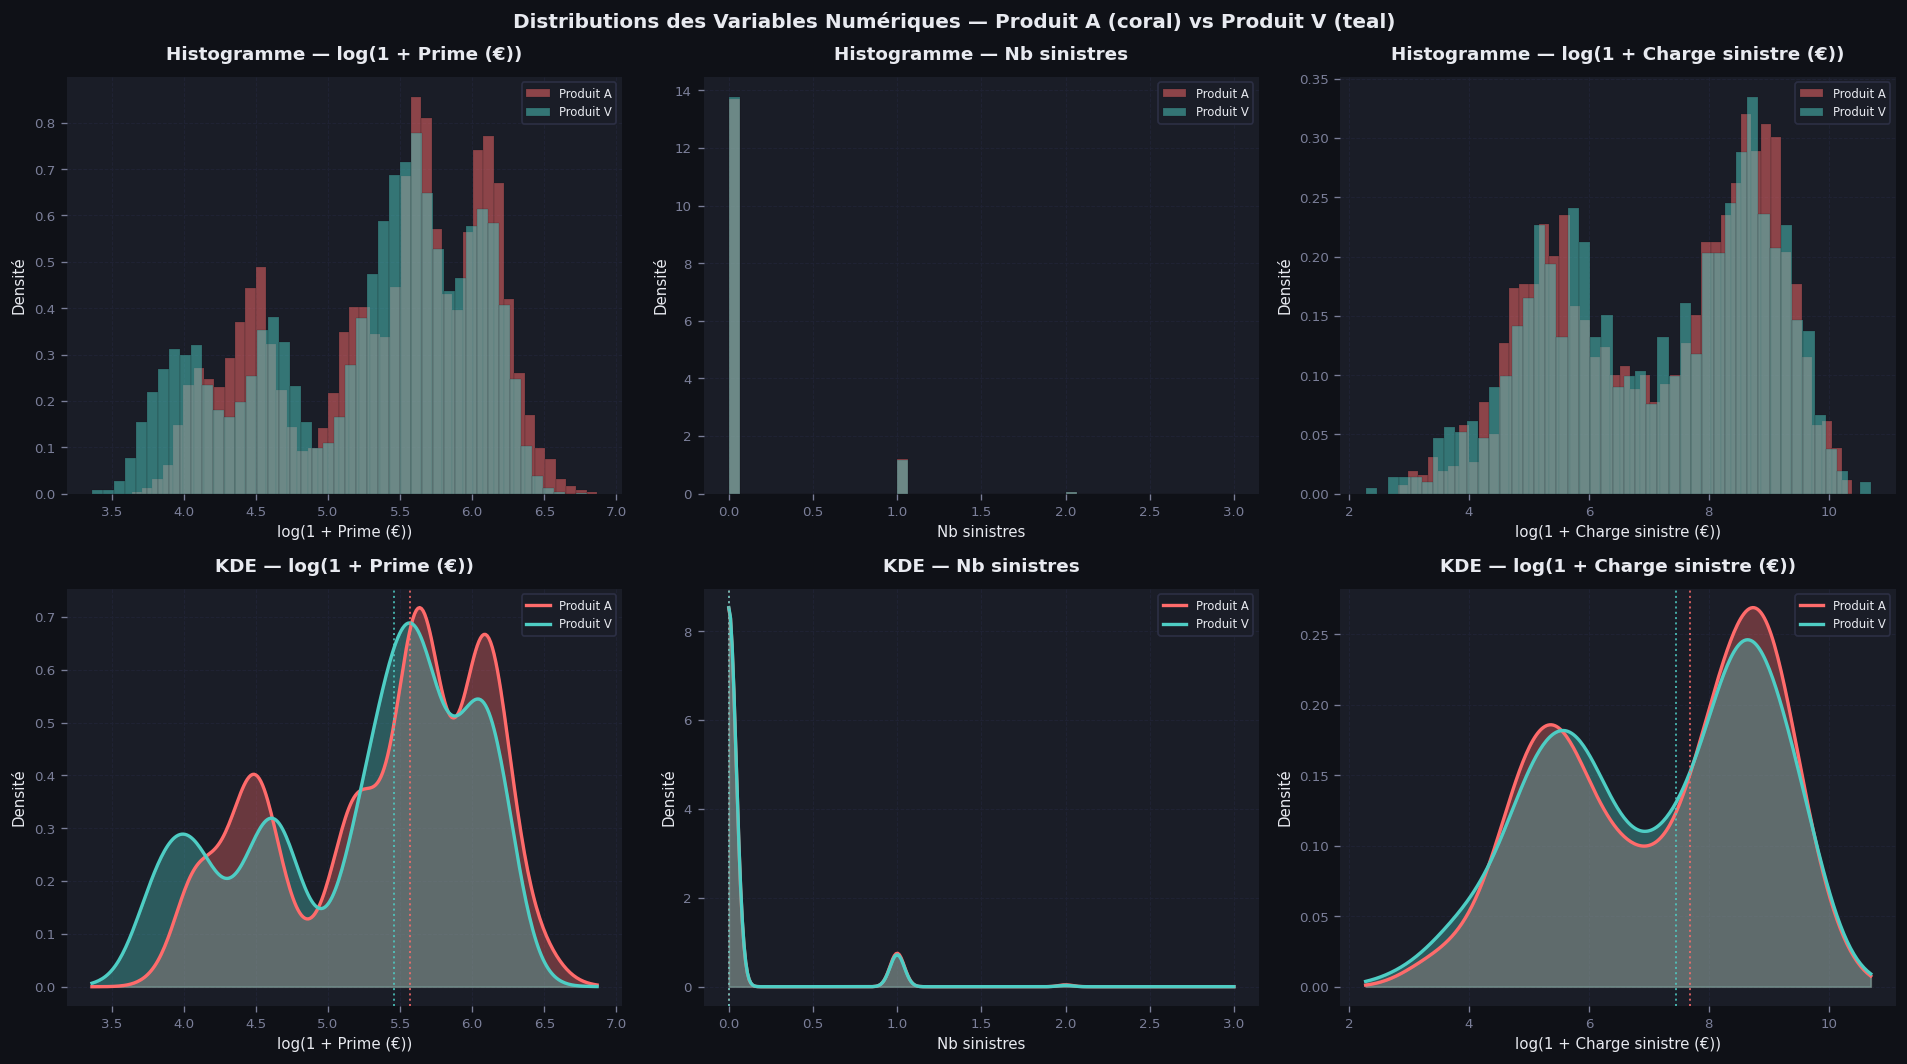

In [13]:
# ── Distributions brutes des variables clés ───────────────────────────────────
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
fig.suptitle("Distributions des Variables Numériques — Produit A (coral) vs Produit V (teal)",
             fontsize=12, fontweight="bold")

pairs = [
    ("prime",           "prime",           "Prime (€)",            True),
    ("nb_sinistres",    "nb_sinistres",     "Nb sinistres",         False),
    ("charge_sinistre", "charge_sinistre",  "Charge sinistre (€)",  True),
]

for col_idx, (col_a, col_v, xlabel, do_log) in enumerate(pairs):
    for row_idx, do_kde in enumerate([False, True]):
        ax = axes[row_idx, col_idx]
        da = df_A[col_a].values
        dv = df_V[col_v].values
        if do_log:
            da = np.log1p(da[da > 0])
            dv = np.log1p(dv[dv > 0])
            xlabel_eff = f"log(1 + {xlabel})"
        else:
            xlabel_eff = xlabel

        if do_kde:
            kde_a = gaussian_kde(da)
            kde_v = gaussian_kde(dv)
            xmin  = min(da.min(), dv.min())
            xmax  = max(da.max(), dv.max())
            xs    = np.linspace(xmin, xmax, 300)
            ax.fill_between(xs, kde_a(xs), alpha=0.35, color=A_MAIN)
            ax.fill_between(xs, kde_v(xs), alpha=0.35, color=V_MAIN)
            ax.plot(xs, kde_a(xs), color=A_MAIN,  lw=2, label="Produit A")
            ax.plot(xs, kde_v(xs), color=V_MAIN, lw=2, label="Produit V")
            ax.axvline(np.median(da), color=A_MAIN,  lw=1.2, ls=":", alpha=0.8)
            ax.axvline(np.median(dv), color=V_MAIN, lw=1.2, ls=":", alpha=0.8)
            ax.set_title(f"KDE — {xlabel_eff}")
            ax.set_ylabel("Densité")
        else:
            ax.hist(da, bins=45, color=A_MAIN, alpha=0.50,
                    density=True, label="Produit A", edgecolor=BG, linewidth=0.2)
            ax.hist(dv, bins=45, color=V_MAIN, alpha=0.50,
                    density=True, label="Produit V", edgecolor=BG, linewidth=0.2)
            ax.set_title(f"Histogramme — {xlabel_eff}")
            ax.set_ylabel("Densité")
        ax.set_xlabel(xlabel_eff)
        ax.legend(fontsize=7)

plt.tight_layout()
plt.show()


## 5. KPIs Globaux

### Définitions

| Indicateur | Formule |
|---|---|
| **Fréquence** | nb sinistres / nb contrats |
| **Sévérité** | charge totale / nb sinistres |
| **Coût moyen** | charge totale / nb contrats |
| **S/P** | charge totale / prime acquise |
| **Loss Ratio** | idem S/P |


In [14]:
def compute_kpis(df: pd.DataFrame) -> dict:
    """Calcule l'ensemble des KPIs techniques d'un portefeuille."""
    n  = len(df)
    p  = df["prime"].sum()
    s  = df["charge_sinistre"].sum()
    ns = int(df["nb_sinistres"].sum())
    return {
        "nb_contrats":       n,
        "prime_totale":      p,
        "prime_moy":         p / n,
        "charge_totale":     s,
        "nb_sinistres":      ns,
        "frequence":         ns / n,
        "severite":          s / ns  if ns > 0 else 0.0,
        "cout_moyen":        s / n,
        "sp_ratio":          s / p   if p  > 0 else 0.0,
        "pct_contrats_avec_sinistre": (df["nb_sinistres"] > 0).mean(),
    }

kpi_A = compute_kpis(df_A)
kpi_V = compute_kpis(df_V)

# Tableau de synthèse formaté
kpi_table = pd.DataFrame({"Produit A": kpi_A, "Produit V": kpi_V}).T
kpi_table.index.name = "Produit"

fmt = {
    "nb_contrats":       "{:,.0f}",
    "prime_totale":      "{:,.0f} €",
    "prime_moy":         "{:.1f} €",
    "charge_totale":     "{:,.0f} €",
    "nb_sinistres":      "{:,.0f}",
    "frequence":         "{:.4f}",
    "severite":          "{:,.0f} €",
    "cout_moyen":        "{:.2f} €",
    "sp_ratio":          "{:.2%}",
    "pct_contrats_avec_sinistre": "{:.2%}",
}
display(
    kpi_table.style
    .format(fmt)
    .background_gradient(subset=["sp_ratio", "frequence"], cmap="RdYlGn_r", axis=0)
    .set_caption("KPIs Globaux — Produit A vs Produit V")
)


,nb_contrats,prime_totale,prime_moy,charge_totale,nb_sinistres,frequence,severite,cout_moyen,sp_ratio,pct_contrats_avec_sinistre
Produit,,,,,,,,,,
Produit A,"18,000","4,852,750 €",269.6 €,"6,252,210 €","1,630",0.0906,"3,836 €",347.34 €,128.84%,8.57%
Produit V,"14,000","3,363,581 €",240.3 €,"4,431,122 €","1,180",0.0843,"3,755 €",316.51 €,131.74%,8.09%


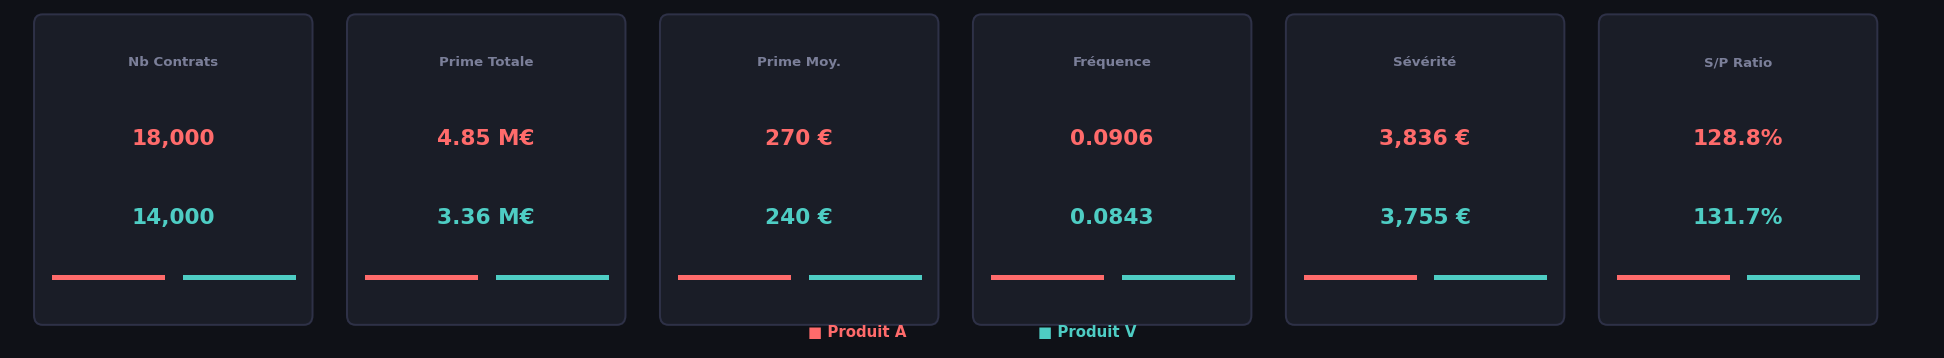

In [15]:
# ── Dashboard 6 cartes KPI ────────────────────────────────────────────────────
metrics = [
    ("Nb Contrats",    f"{kpi_A['nb_contrats']:,}",           f"{kpi_V['nb_contrats']:,}"),
    ("Prime Totale",   f"{kpi_A['prime_totale']/1e6:.2f} M€", f"{kpi_V['prime_totale']/1e6:.2f} M€"),
    ("Prime Moy.",     f"{kpi_A['prime_moy']:.0f} €",         f"{kpi_V['prime_moy']:.0f} €"),
    ("Fréquence",      f"{kpi_A['frequence']:.4f}",            f"{kpi_V['frequence']:.4f}"),
    ("Sévérité",       f"{kpi_A['severite']:,.0f} €",          f"{kpi_V['severite']:,.0f} €"),
    ("S/P Ratio",      f"{kpi_A['sp_ratio']:.1%}",             f"{kpi_V['sp_ratio']:.1%}"),
]

fig = plt.figure(figsize=(16, 3))
fig.patch.set_facecolor(BG)

for i, (label, va, vv) in enumerate(metrics):
    ax = fig.add_axes([0.01 + i * 0.163, 0.05, 0.148, 0.88])
    ax.set_facecolor(PANEL)
    ax.axis("off")
    ax.set_xlim(0, 1); ax.set_ylim(0, 1)
    rect = FancyBboxPatch((0.04, 0.04), 0.92, 0.92,
        boxstyle="round,pad=0.03", lw=1.2, ec=BORDER, fc=PANEL)
    ax.add_patch(rect)
    ax.text(0.5, 0.84, label, ha="center", va="center",
            color=MUTED, fontsize=8, fontweight="bold")
    ax.text(0.5, 0.60, va, ha="center", va="center",
            color=A_MAIN, fontsize=13, fontweight="bold")
    ax.text(0.5, 0.35, vv, ha="center", va="center",
            color=V_MAIN, fontsize=13, fontweight="bold")
    ax.plot([0.08, 0.46], [0.16, 0.16], color=A_MAIN, lw=3,
            transform=ax.transAxes, clip_on=False)
    ax.plot([0.54, 0.92], [0.16, 0.16], color=V_MAIN, lw=3,
            transform=ax.transAxes, clip_on=False)

# Légende
leg_ax = fig.add_axes([0.0, 0.0, 1.0, 0.08])
leg_ax.axis("off")
leg_ax.text(0.44, 0.5, "■ Produit A", color=A_MAIN, fontsize=9,
            fontweight="bold", ha="center", va="center")
leg_ax.text(0.56, 0.5, "■ Produit V", color=V_MAIN, fontsize=9,
            fontweight="bold", ha="center", va="center")

plt.show()


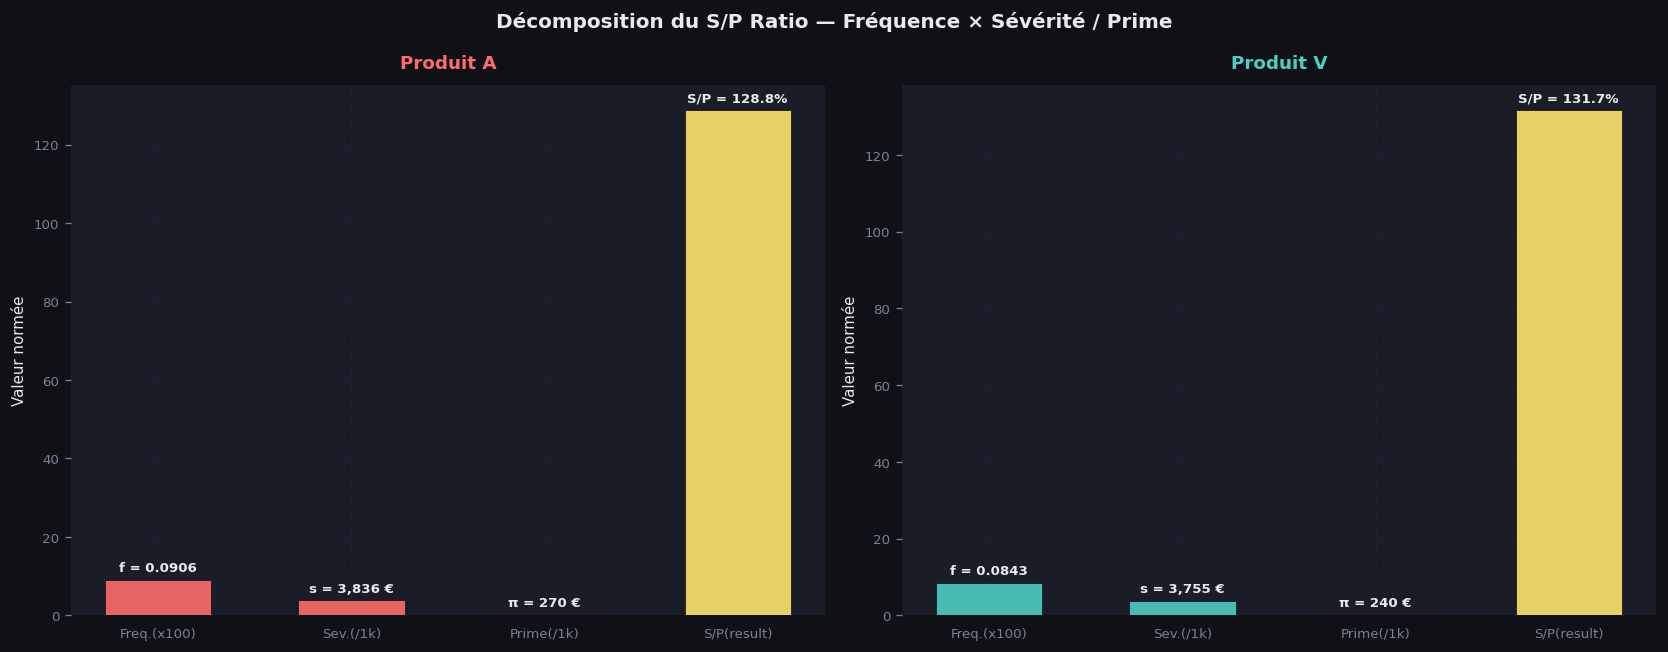

In [16]:
# ── Décomposition S/P : S/P = Fréquence × Sévérité / Prime moyenne ────────────
#   waterfall chart
fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))
fig.suptitle("Décomposition du S/P Ratio — Fréquence × Sévérité / Prime",
             fontsize=12, fontweight="bold")

for ax, (label, kpi, color) in zip(axes, [
    ("Produit A", kpi_A, A_MAIN),
    ("Produit V", kpi_V, V_MAIN),
]):
    # S/P = freq × sev / prime_moy
    freq  = kpi["frequence"]
    sev   = kpi["severite"]
    prime = kpi["prime_moy"]
    sp    = kpi["sp_ratio"]

    categories = ["Freq.(x100)", "Sev.(/1k)", "Prime(/1k)", "S/P(result)"]
    values     = [freq * 100, sev / 1000, prime / 1000, sp * 100]

    bar_colors = [color, color, "#E74C3C", ACCENT]
    alphas     = [0.75, 0.75, 0.60, 1.00]

    bars = ax.bar(categories, values, color=bar_colors,
                  alpha=0.9, width=0.55, edgecolor=BG, linewidth=0.5)

    # Annotations valeur brute
    raw_labels = [
        f"f = {freq:.4f}",
        f"s = {sev:,.0f} €",
        f"π = {prime:.0f} €",
        f"S/P = {sp:.1%}",
    ]
    for bar, rl, v in zip(bars, raw_labels, values):
        ax.text(bar.get_x() + bar.get_width() / 2,
                bar.get_height() + ax.get_ylim()[1] * 0.01,
                rl, ha="center", va="bottom", fontsize=8, color=TEXT, fontweight="bold")

    ax.set_title(label, color=color, fontsize=11)
    ax.set_ylabel("Valeur normée")
    ax.tick_params(axis="x", which="both", bottom=False)

plt.tight_layout()
plt.show()


## 6. Analyse par Garantie

In [17]:
def kpis_by_group(df: pd.DataFrame, group_col: str,
                  canonical_order: list | None = None) -> pd.DataFrame:
    """
    Calcule les KPIs techniques par groupe (garantie, carburant, âge, …).

    Paramètres
    ----------
    df            : DataFrame harmonisé (doit contenir prime, nb_sinistres, charge_sinistre)
    group_col     : colonne de segmentation
    canonical_order : ordre souhaité des lignes (optionnel)

    Retourne
    --------
    DataFrame avec les KPIs indexé par group_col
    """
    rows = []
    for val, grp in df.groupby(group_col, observed=True):
        k = compute_kpis(grp)
        k[group_col] = val
        rows.append(k)
    out = pd.DataFrame(rows).set_index(group_col)
    if canonical_order:
        ordered   = [g for g in canonical_order if g in out.index]
        remaining = [g for g in out.index       if g not in canonical_order]
        out = out.reindex(ordered + remaining)
    return out


kpi_gar_A = kpis_by_group(df_A, "garantie_h", GAR_ORDER)
kpi_gar_V = kpis_by_group(df_V, "garantie_h", GAR_ORDER)

# ─── Affichage formaté avec gradient S/P ─────────────────────────────────────
fmt_gar = {
    "nb_contrats":  "{:,.0f}", "prime_totale":  "{:,.0f} €",
    "prime_moy":    "{:.0f} €","charge_totale": "{:,.0f} €",
    "nb_sinistres": "{:,.0f}", "frequence":     "{:.4f}",
    "severite":     "{:,.0f} €","cout_moyen":   "{:.1f} €",
    "sp_ratio":     "{:.2%}",  "pct_contrats_avec_sinistre": "{:.2%}",
}
cols_show = ["nb_contrats", "prime_moy", "frequence", "severite", "cout_moyen", "sp_ratio"]

print("── Produit A — KPIs par garantie ──")
display(
    kpi_gar_A[cols_show].style.format({c: fmt_gar[c] for c in cols_show})
    .background_gradient(subset=["sp_ratio", "frequence"], cmap="RdYlGn_r")
    .bar(subset=["nb_contrats"], color=A_LIGHT)
)


── Produit A — KPIs par garantie ──


,nb_contrats,prime_moy,frequence,severite,cout_moyen,sp_ratio
garantie_h,,,,,,
RC,"5,430",292 €,0.0696,"4,458 €",310.4 €,106.31%
Dommages,"4,990",471 €,0.0920,"7,193 €",661.6 €,140.34%
Vol,"2,765",188 €,0.0463,"8,556 €",396.1 €,211.16%
Bris de Glace,"3,023",94 €,0.1154,332 €,38.3 €,40.75%
Assistance,"1,792",63 €,0.1763,172 €,30.4 €,48.55%


In [18]:
print("── Produit V — KPIs par garantie ──")
display(
    kpi_gar_V[cols_show].style.format({c: fmt_gar[c] for c in cols_show})
    .background_gradient(subset=["sp_ratio", "frequence"], cmap="RdYlGn_r")
    .bar(subset=["nb_contrats"], color=V_LIGHT)
)


── Produit V — KPIs par garantie ──


,nb_contrats,prime_moy,frequence,severite,cout_moyen,sp_ratio
garantie_h,,,,,,
RC,"3,926",272 €,0.0634,"4,565 €",289.5 €,106.61%
Dommages,"3,543",438 €,0.0920,"7,330 €",674.4 €,153.89%
Vol,"2,026",199 €,0.0424,"8,669 €",368.0 €,185.17%
Bris de Glace,"2,199",100 €,0.1110,323 €,35.9 €,35.89%
Assistance,"1,295",58 €,0.1583,159 €,25.1 €,43.52%
Protection Juridique,"1,011",47 €,0.0692,684 €,47.4 €,101.02%


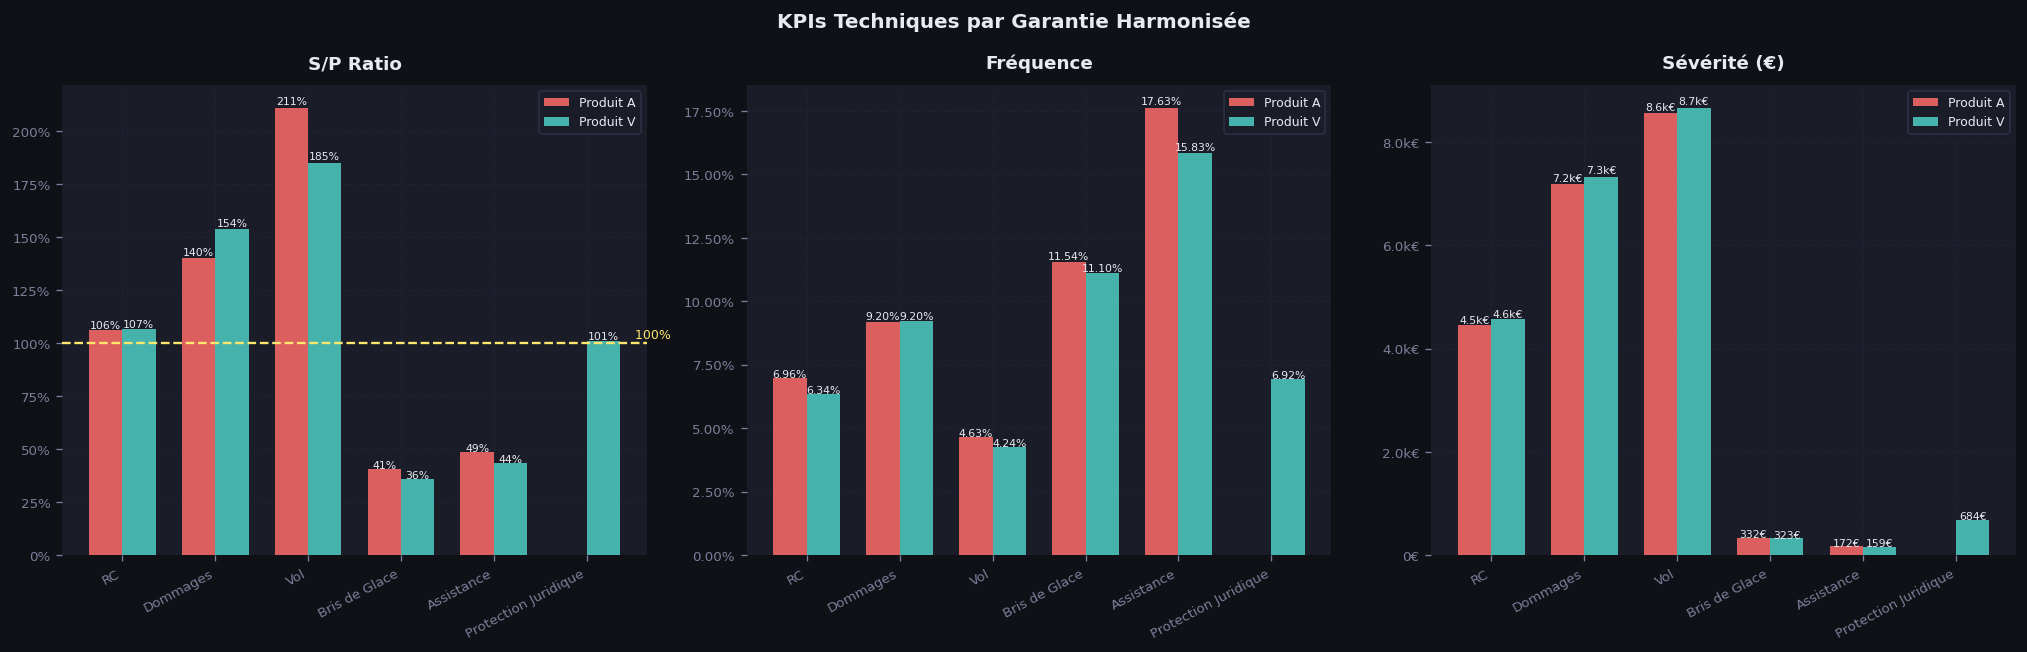

In [19]:
# ── Graphique 1 : bar charts triple (S/P, Fréquence, Sévérité) ───────────────
gars_all = [g for g in GAR_ORDER
            if g in kpi_gar_A.index or g in kpi_gar_V.index]

def safe(df_k, gar, col):
    return float(df_k.loc[gar, col]) if gar in df_k.index else 0.0

x, w = np.arange(len(gars_all)), 0.36

fig, axes = plt.subplots(1, 3, figsize=(17, 5.5))
fig.suptitle("KPIs Techniques par Garantie Harmonisée", fontsize=12, fontweight="bold")

for ax, (col, title, formatter, ref) in zip(axes, [
    ("sp_ratio",  "S/P Ratio",      lambda v,_: f"{v:.0%}",  1.0),
    ("frequence", "Fréquence",      lambda v,_: f"{v:.2%}",  None),
    ("severite",  "Sévérité (€)",   fmt_eur,                  None),
]):
    va = [safe(kpi_gar_A, g, col) for g in gars_all]
    vv = [safe(kpi_gar_V, g, col) for g in gars_all]
    ba = ax.bar(x - w / 2, va, w, color=A_MAIN, alpha=0.85, label="Produit A")
    bv = ax.bar(x + w / 2, vv, w, color=V_MAIN, alpha=0.85, label="Produit V")
    if ref is not None:
        ax.axhline(ref, color=ACCENT, ls="--", lw=1.4, zorder=4)
        ax.text(len(gars_all) - 0.1, ref * 1.01, f" {ref:.0%}",
                color=ACCENT, fontsize=7.5, va="bottom", ha="right")
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(formatter))
    ax.set_xticks(x)
    ax.set_xticklabels(gars_all, rotation=28, ha="right", fontsize=8)
    ax.set_title(title)
    ax.legend(fontsize=7.5)
    # annotations discrètes
    for b, v in zip(ba, va):
        if v:
            ax.text(b.get_x() + b.get_width() / 2, v * 1.008,
                    formatter(v, None), ha="center", fontsize=6.5, color=TEXT)
    for b, v in zip(bv, vv):
        if v:
            ax.text(b.get_x() + b.get_width() / 2, v * 1.008,
                    formatter(v, None), ha="center", fontsize=6.5, color=TEXT)

plt.tight_layout()
plt.show()


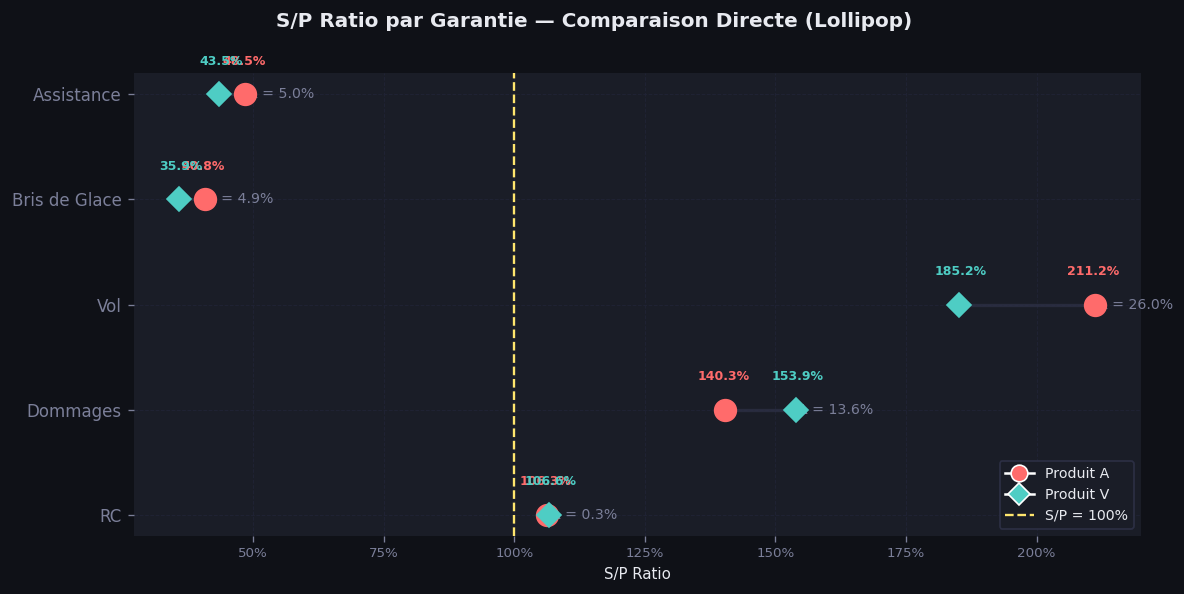

In [20]:
# ── Graphique 2 : Lollipop S/P par garantie commune ─────────────────────────
gars_common = [g for g in GAR_ORDER
               if g in kpi_gar_A.index and g in kpi_gar_V.index]

sp_a = [kpi_gar_A.loc[g, "sp_ratio"] for g in gars_common]
sp_v = [kpi_gar_V.loc[g, "sp_ratio"] for g in gars_common]

fig, ax = plt.subplots(figsize=(10, 5))
fig.suptitle("S/P Ratio par Garantie — Comparaison Directe (Lollipop)",
             fontsize=12, fontweight="bold")

for i, (va, vv, g) in enumerate(zip(sp_a, sp_v, gars_common)):
    lo, hi = min(va, vv), max(va, vv)
    # segment entre les deux points
    ax.hlines(i, lo, hi, color=BORDER, lw=2, alpha=0.7, zorder=2)
    ax.plot(va, i, "o", color=A_MAIN, ms=13, zorder=5)
    ax.plot(vv, i, "D", color=V_MAIN, ms=10, zorder=5)
    # Δ
    ax.text(hi + 0.005, i, f"Δ = {abs(va - vv):.1%}",
            va="center", fontsize=8.5, color=MUTED)
    # valeurs
    ax.text(va - 0.003, i + 0.28, f"{va:.1%}",
            ha="center", fontsize=7.5, color=A_MAIN, fontweight="bold")
    ax.text(vv + 0.003, i + 0.28, f"{vv:.1%}",
            ha="center", fontsize=7.5, color=V_MAIN, fontweight="bold")

ax.axvline(1.0, color=ACCENT, ls="--", lw=1.4, label="S/P = 100%")
ax.set_yticks(range(len(gars_common)))
ax.set_yticklabels(gars_common, fontsize=10)
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f"{v:.0%}"))
ax.set_xlabel("S/P Ratio")

legend_handles = [
    Line2D([0], [0], marker="o", color="w", markerfacecolor=A_MAIN, ms=10, label="Produit A"),
    Line2D([0], [0], marker="D", color="w", markerfacecolor=V_MAIN, ms=9,  label="Produit V"),
    Line2D([0], [0], color=ACCENT, ls="--", lw=1.4, label="S/P = 100%"),
]
ax.legend(handles=legend_handles, fontsize=8.5, loc="lower right")

plt.tight_layout()
plt.show()


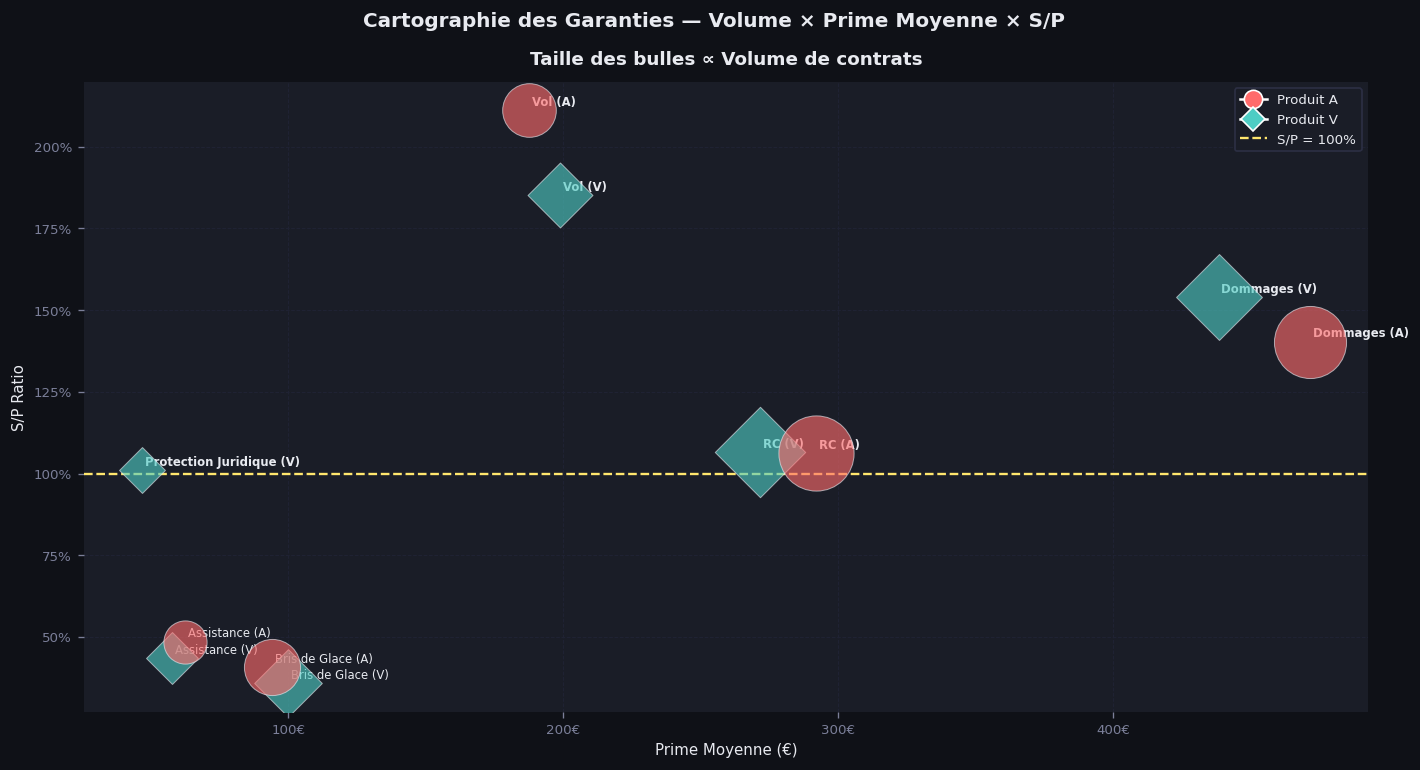

In [21]:
# ── Graphique 3 : Bubble chart volume × prime × S/P par garantie ─────────────
fig, ax = plt.subplots(figsize=(12, 6.5))
fig.suptitle("Cartographie des Garanties — Volume × Prime Moyenne × S/P",
             fontsize=12, fontweight="bold")
ax.set_facecolor(PANEL)

for prod, kpi_g, marker, color, zorder in [
    ("Produit A", kpi_gar_A, "o", A_MAIN, 5),
    ("Produit V", kpi_gar_V, "D", V_MAIN, 4),
]:
    for gar in kpi_g.index:
        n_c  = kpi_g.loc[gar, "nb_contrats"]
        pm   = kpi_g.loc[gar, "prime_moy"]
        sp   = kpi_g.loc[gar, "sp_ratio"]
        size = n_c / (kpi_A["nb_contrats"] + kpi_V["nb_contrats"]) * 12000

        col = A_MAIN if color == A_MAIN else V_MAIN
        ax.scatter(pm, sp, s=size, color=col, alpha=0.62, marker=marker,
                   edgecolors=TEXT, linewidths=0.6, zorder=zorder)
        ax.text(pm + 1, sp + 0.005, f"{gar} ({prod[-1]})",
                fontsize=7, color=TEXT, va="bottom", ha="left",
                fontweight="bold" if sp > 1.0 else "normal")

ax.axhline(1.0, color=ACCENT, ls="--", lw=1.4, label="S/P = 100%", zorder=3)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f"{v:.0%}"))
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f"{v:.0f}€"))
ax.set_xlabel("Prime Moyenne (€)")
ax.set_ylabel("S/P Ratio")
ax.set_title("Taille des bulles ∝ Volume de contrats")

handles = [
    Line2D([0],[0], marker="o", color="w", markerfacecolor=A_MAIN, ms=11, label="Produit A"),
    Line2D([0],[0], marker="D", color="w", markerfacecolor=V_MAIN, ms=10, label="Produit V"),
    Line2D([0],[0], color=ACCENT, ls="--", lw=1.4, label="S/P = 100%"),
]
ax.legend(handles=handles, fontsize=8)
plt.tight_layout()
plt.show()


## 7. Analyse Univariée — Tranche d'Âge

> **Rappel mapping :** Produit A stocke les tranches directement.  
> Produit V stocke l'âge brut (int), converti en tranches identiques à l'étape 3.

L'âge est le facteur tarifaire n°1 en assurance auto.  
On analyse : distribution, relativités de fréquence et de S/P, sévérité, prime.


In [22]:
# ─── Calcul des indicateurs par tranche ──────────────────────────────────────
def age_kpis(df: pd.DataFrame) -> pd.DataFrame:
    grp = df.groupby("age_tranche_h", observed=False)
    cnt = grp.size()
    pm  = grp["prime"].mean()
    frq = grp.apply(lambda x: x["nb_sinistres"].sum() / len(x))
    sev = (df[df["nb_sinistres"] > 0]
             .groupby("age_tranche_h", observed=False)["charge_sinistre"].median())
    sp  = grp.apply(lambda x: x["charge_sinistre"].sum() / x["prime"].sum())
    return pd.DataFrame({
        "pct_contrats": cnt / cnt.sum() * 100,
        "prime_moy":    pm,
        "frequence":    frq,
        "sev_mediane":  sev,
        "sp_ratio":     sp,
        # relativités (base 100 = moyenne portefeuille)
        "rel_frequence": frq / frq.mean() * 100,
        "rel_sp":        sp  / sp.mean()  * 100,
        "rel_prime":     pm  / pm.mean()  * 100,
    }).reindex(AGE_ORDER)

age_A = age_kpis(df_A)
age_V = age_kpis(df_V)

display(
    age_A[["pct_contrats", "prime_moy", "frequence", "sev_mediane", "sp_ratio",
           "rel_frequence", "rel_sp"]]
    .style
    .format({
        "pct_contrats": "{:.1f}%", "prime_moy":  "{:.0f} €",
        "frequence":    "{:.4f}",  "sev_mediane": "{:,.0f} €",
        "sp_ratio":     "{:.2%}",  "rel_frequence": "{:.1f}",
        "rel_sp":       "{:.1f}",
    })
    .background_gradient(subset=["rel_sp", "rel_frequence"], cmap="RdYlGn_r")
    .set_caption("Produit A — indicateurs par tranche d'âge (rel. base 100 = moy. portefeuille)")
)


,pct_contrats,prime_moy,frequence,sev_mediane,sp_ratio,rel_frequence,rel_sp
age_tranche_h,,,,,,,
18-25,9.9%,367 €,0.1240,"1,109 €",114.41%,134.1,88.5
26-35,21.7%,261 €,0.0942,"2,635 €",152.33%,101.9,117.9
36-45,25.0%,261 €,0.0866,"2,211 €",124.86%,93.6,96.6
46-55,22.4%,259 €,0.0852,"1,957 €",114.55%,92.2,88.6
56-65,14.0%,259 €,0.0794,"2,825 €",133.20%,85.8,103.1
65+,7.0%,242 €,0.0854,"2,201 €",136.04%,92.4,105.3


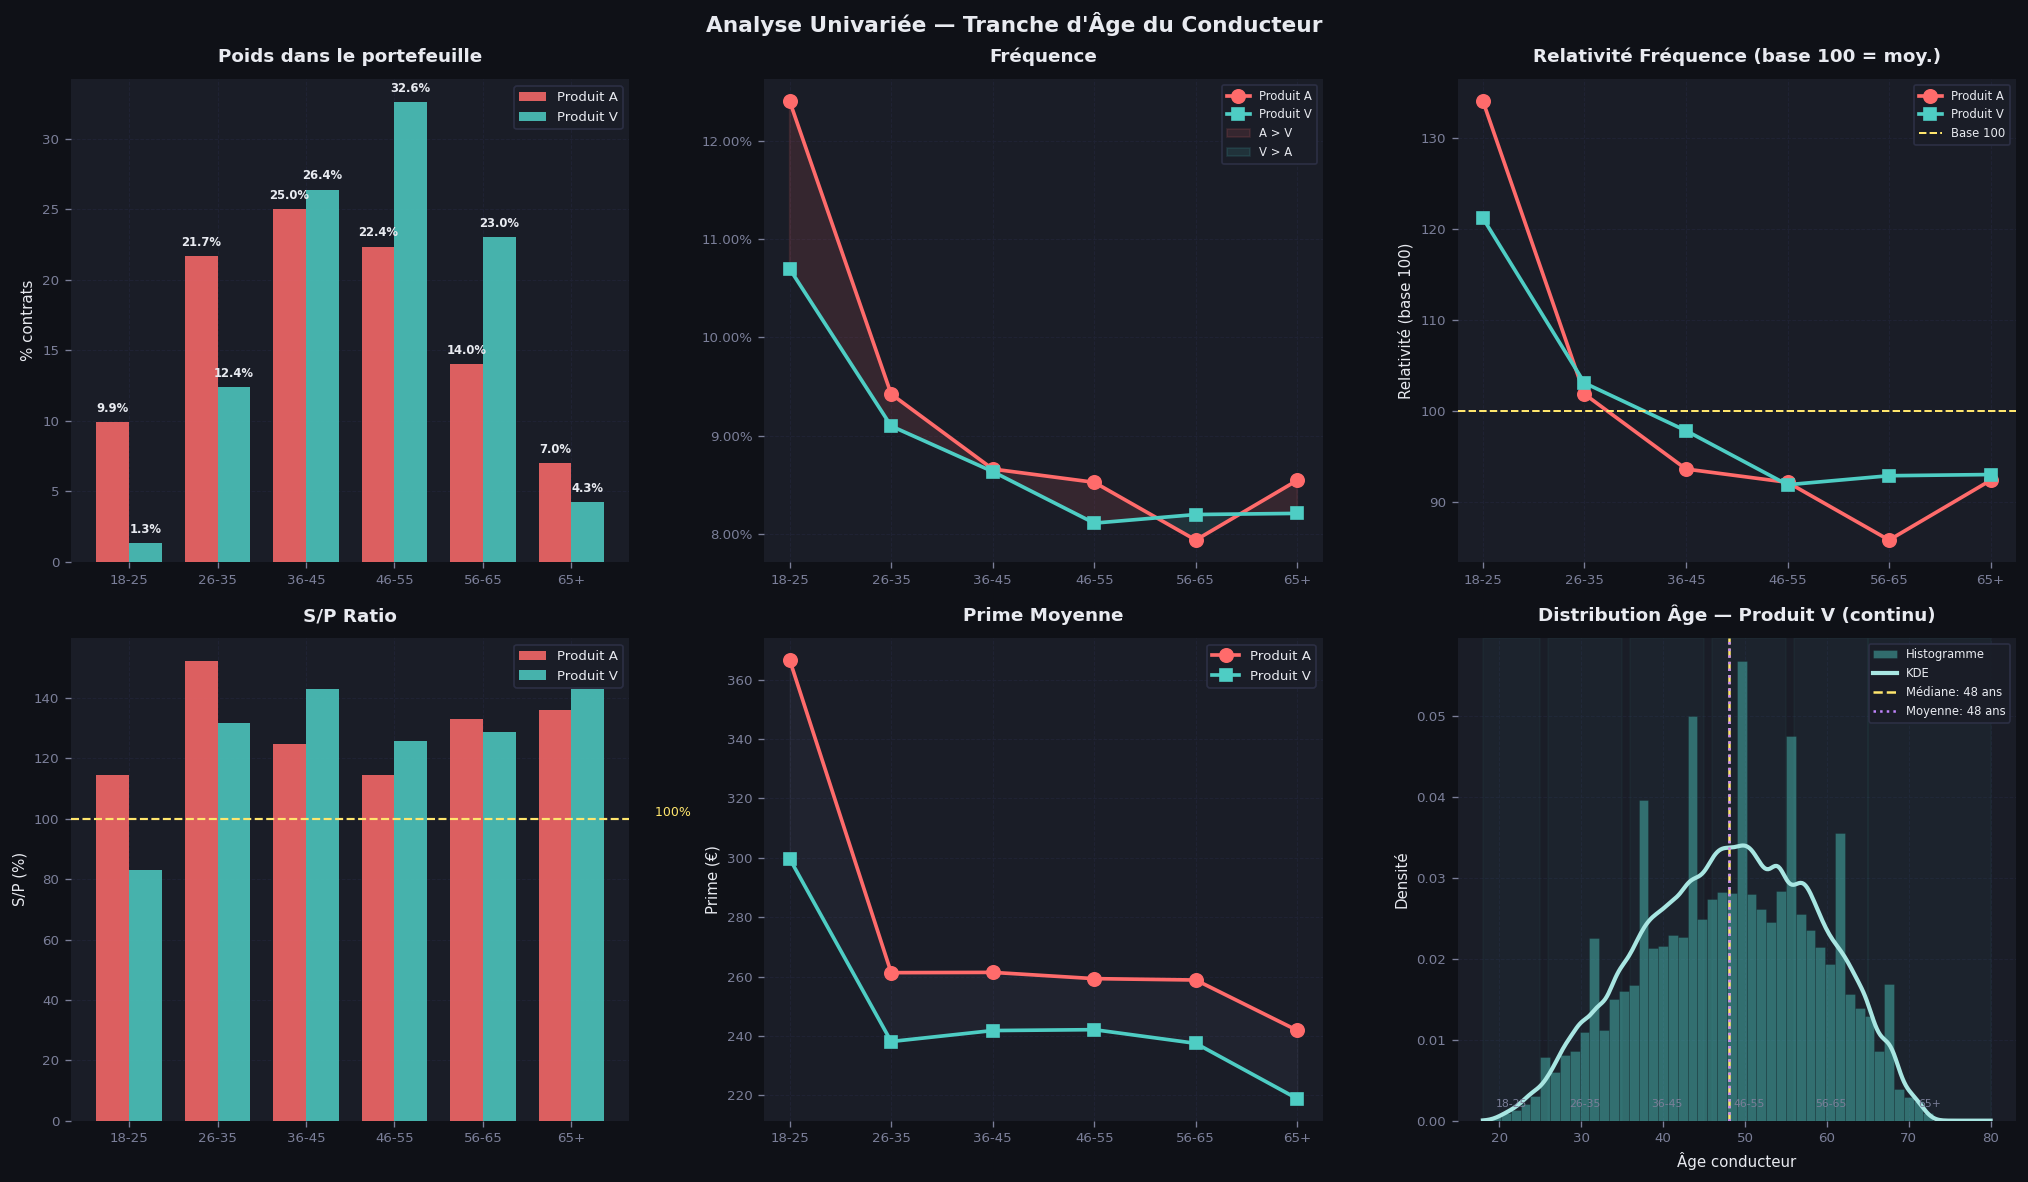

In [23]:
fig, axes = plt.subplots(2, 3, figsize=(17, 10))
fig.suptitle("Analyse Univariée — Tranche d'Âge du Conducteur",
             fontsize=13, fontweight="bold")

x = np.arange(len(AGE_ORDER)); w = 0.37

# 1. Distribution (% portefeuille)
ax = axes[0, 0]
b_a = ax.bar(x - w/2, age_A["pct_contrats"], w, color=A_MAIN, alpha=0.85, label="Produit A")
b_v = ax.bar(x + w/2, age_V["pct_contrats"], w, color=V_MAIN, alpha=0.85, label="Produit V")
annotate_bars(ax, b_a, fmt="{:.1f}%"); annotate_bars(ax, b_v, fmt="{:.1f}%")
ax.set_xticks(x); ax.set_xticklabels(AGE_ORDER)
ax.set_ylabel("% contrats"); ax.set_title("Poids dans le portefeuille"); ax.legend()

# 2. Fréquence — courbes avec fill
ax = axes[0, 1]
xi = range(len(AGE_ORDER))
ax.plot(AGE_ORDER, age_A["frequence"], "o-", color=A_MAIN, lw=2.2, ms=8, label="Produit A", zorder=5)
ax.plot(AGE_ORDER, age_V["frequence"], "s-", color=V_MAIN, lw=2.2, ms=7, label="Produit V", zorder=5)
ax.fill_between(xi, age_A["frequence"], age_V["frequence"],
                where=age_A["frequence"] >= age_V["frequence"],
                alpha=0.12, color=A_MAIN, interpolate=True, label="A > V")
ax.fill_between(xi, age_A["frequence"], age_V["frequence"],
                where=age_A["frequence"] <  age_V["frequence"],
                alpha=0.12, color=V_MAIN, interpolate=True, label="V > A")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f"{v:.2%}"))
ax.set_xticks(xi); ax.set_xticklabels(AGE_ORDER)
ax.set_title("Fréquence"); ax.legend(fontsize=7)

# 3. Relativités fréquence (base 100)
ax = axes[0, 2]
ax.plot(AGE_ORDER, age_A["rel_frequence"], "o-", color=A_MAIN, lw=2.2, ms=8, label="Produit A")
ax.plot(AGE_ORDER, age_V["rel_frequence"], "s-", color=V_MAIN, lw=2.2, ms=7, label="Produit V")
ax.axhline(100, color=ACCENT, ls="--", lw=1.2, label="Base 100")
ax.set_xticks(range(len(AGE_ORDER))); ax.set_xticklabels(AGE_ORDER)
ax.set_ylabel("Relativité (base 100)"); ax.set_title("Relativité Fréquence (base 100 = moy.)"); ax.legend(fontsize=7)

# 4. S/P Ratio
ax = axes[1, 0]
b_a = ax.bar(x - w/2, age_A["sp_ratio"] * 100, w, color=A_MAIN, alpha=0.85, label="Produit A")
b_v = ax.bar(x + w/2, age_V["sp_ratio"] * 100, w, color=V_MAIN, alpha=0.85, label="Produit V")
ax.axhline(100, color=ACCENT, ls="--", lw=1.3, zorder=4)
ax.text(len(AGE_ORDER) - 0.1, 101, " 100%", color=ACCENT, fontsize=7.5)
ax.set_xticks(x); ax.set_xticklabels(AGE_ORDER)
ax.set_ylabel("S/P (%)"); ax.set_title("S/P Ratio"); ax.legend()

# 5. Prime moyenne
ax = axes[1, 1]
ax.plot(AGE_ORDER, age_A["prime_moy"], "o-", color=A_MAIN, lw=2.2, ms=8, label="Produit A")
ax.plot(AGE_ORDER, age_V["prime_moy"], "s-", color=V_MAIN, lw=2.2, ms=7, label="Produit V")
ax.fill_between(range(len(AGE_ORDER)), age_A["prime_moy"], age_V["prime_moy"],
                alpha=0.07, color=MUTED)
ax.set_xticks(range(len(AGE_ORDER))); ax.set_xticklabels(AGE_ORDER)
ax.set_ylabel("Prime (€)"); ax.set_title("Prime Moyenne"); ax.legend()

# 6. Distribution continue âge (Produit V) + rugplot synthétique
ax = axes[1, 2]
ax.set_facecolor(PANEL)
age_vals = df_V["age_conducteur"].values
ax.hist(age_vals, bins=45, color=V_MAIN, alpha=0.45,
        density=True, edgecolor=BG, lw=0.3, label="Histogramme")
kde = gaussian_kde(age_vals, bw_method=0.08)
xs  = np.linspace(18, 80, 300)
ax.plot(xs, kde(xs), color=V_LIGHT, lw=2.5, label="KDE")
# Lignes de médiane et moyenne
ax.axvline(np.median(age_vals), color=ACCENT,  ls="--", lw=1.5,
           label=f"Médiane: {np.median(age_vals):.0f} ans")
ax.axvline(np.mean(age_vals),   color=ACCENT2, ls=":",  lw=1.5,
           label=f"Moyenne: {np.mean(age_vals):.0f} ans")
# Bandes tranches
for lo, hi, lbl in zip([18,26,36,46,56,65],[25,35,45,55,65,80], AGE_ORDER):
    ax.axvspan(lo, hi, alpha=0.04, color=V_MAIN)
    ax.text((lo + hi) / 2, kde(xs).max() * 0.05, lbl,
            ha="center", fontsize=6.5, color=MUTED)
ax.set_xlabel("Âge conducteur"); ax.set_ylabel("Densité")
ax.set_title("Distribution Âge — Produit V (continu)"); ax.legend(fontsize=7)

plt.tight_layout()
plt.show()


## 8. Analyse Univariée — Carburant

In [24]:
carb_A = kpis_by_group(df_A, "carburant_h", CARB_ORDER)
carb_V = kpis_by_group(df_V, "carburant_h", CARB_ORDER)

# Relativités
for df_k, kpi_g in [(carb_A, kpi_A), (carb_V, kpi_V)]:
    df_k["rel_freq"] = df_k["frequence"] / kpi_g["frequence"] * 100
    df_k["rel_sp"]   = df_k["sp_ratio"]  / kpi_g["sp_ratio"]  * 100
    df_k["rel_prime"]= df_k["prime_moy"] / kpi_g["prime_moy"] * 100

display(
    carb_A[["nb_contrats", "prime_moy", "frequence", "sp_ratio",
            "rel_freq", "rel_sp", "rel_prime"]]
    .style
    .format({
        "nb_contrats": "{:,.0f}", "prime_moy": "{:.0f} €",
        "frequence": "{:.4f}", "sp_ratio": "{:.2%}",
        "rel_freq": "{:.1f}", "rel_sp": "{:.1f}", "rel_prime": "{:.1f}",
    })
    .background_gradient(subset=["rel_sp", "rel_freq"], cmap="RdYlGn_r")
    .set_caption("Produit A — relativités carburant (base 100 = portefeuille)")
)


,nb_contrats,prime_moy,frequence,sp_ratio,rel_freq,rel_sp,rel_prime
carburant_h,,,,,,,
Essence,"6,785",276 €,0.0930,126.37%,102.7,98.1,102.5
Diesel,"6,314",276 €,0.0901,125.30%,99.5,97.3,102.2
Hybride/Electrique,"3,829",248 €,0.0883,136.71%,97.5,106.1,91.9
Autres,"1,072",270 €,0.0858,140.34%,94.8,108.9,100.2


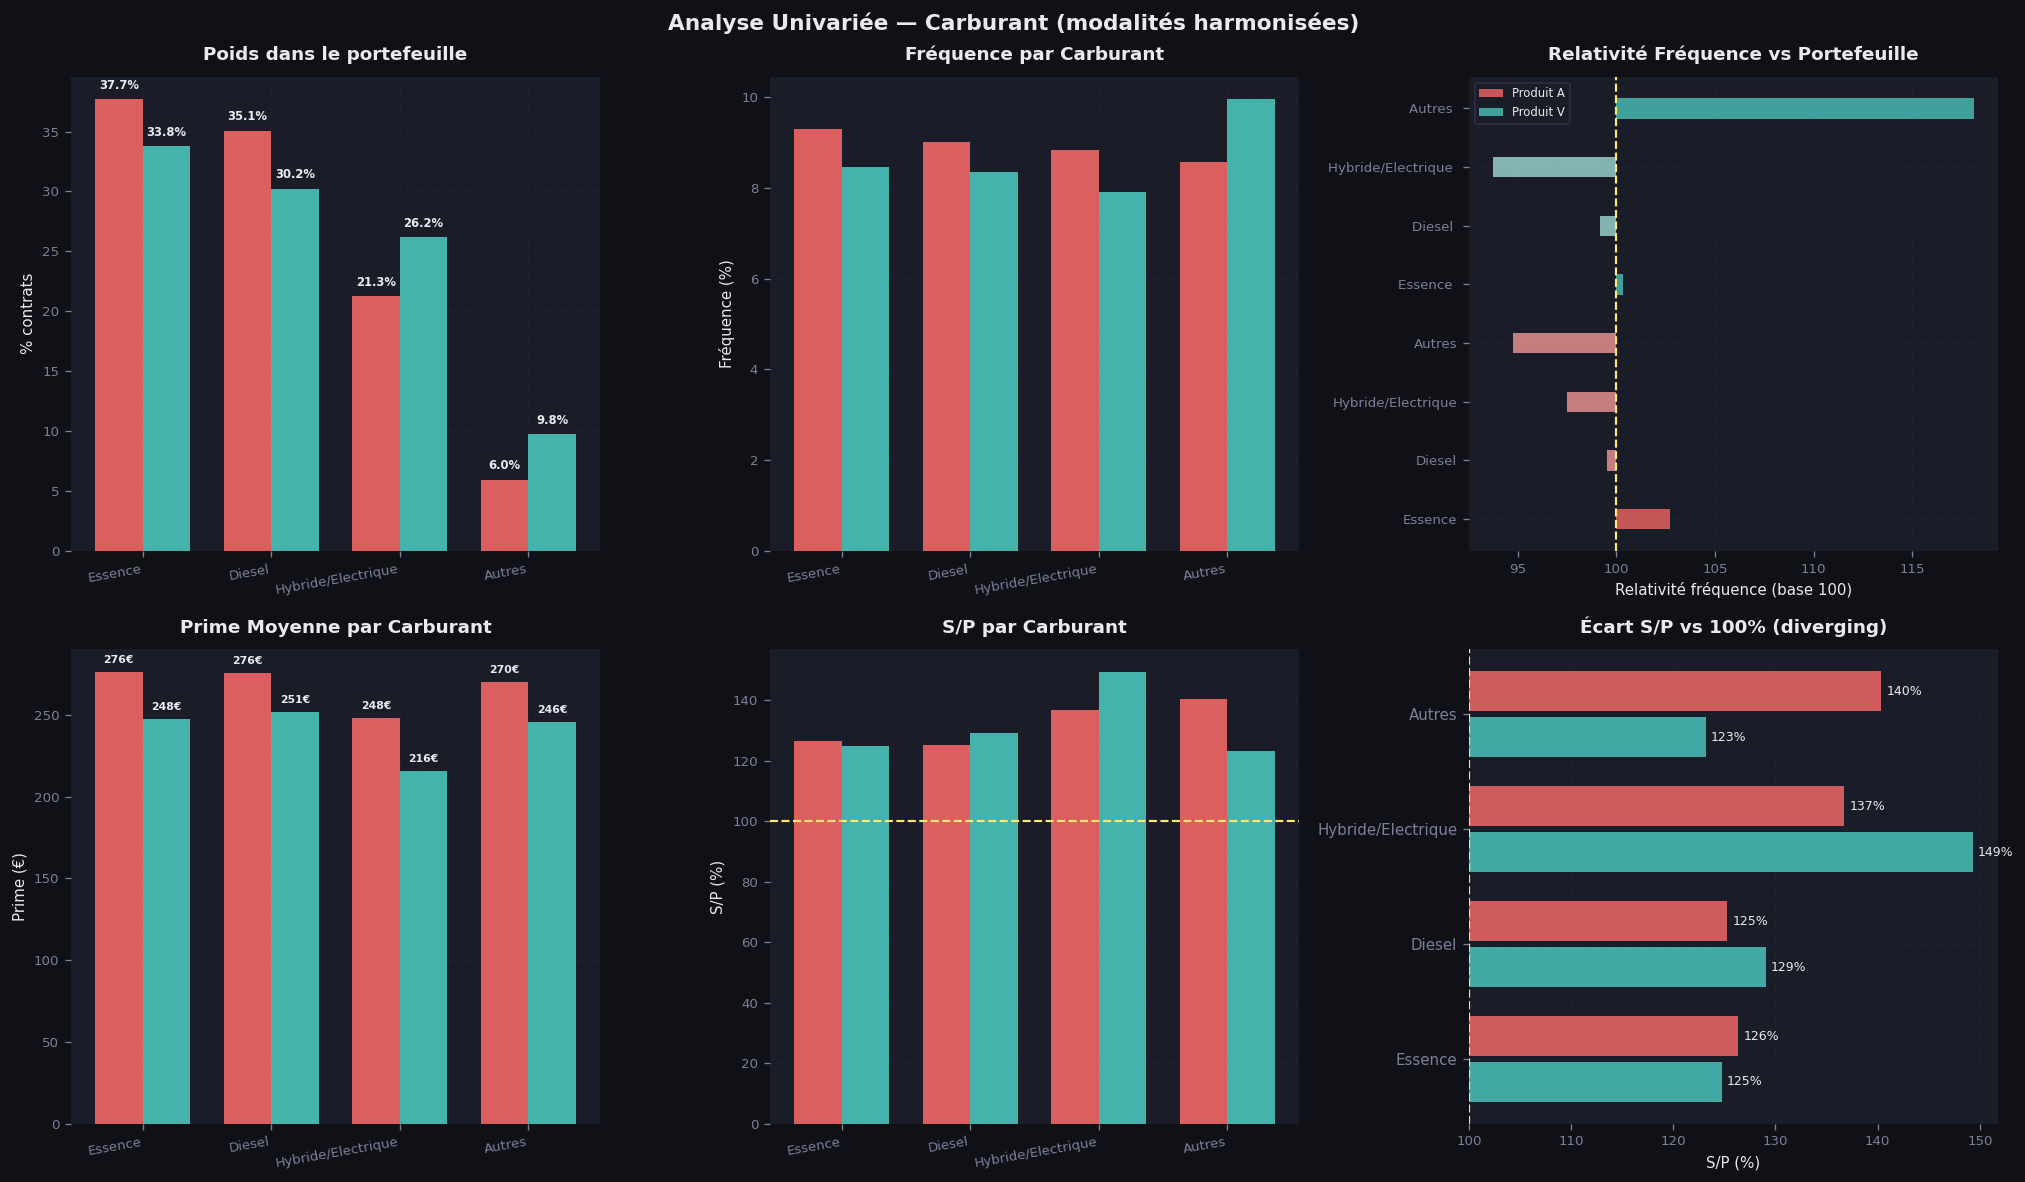

In [25]:
fig, axes = plt.subplots(2, 3, figsize=(17, 10))
fig.suptitle("Analyse Univariée — Carburant (modalités harmonisées)",
             fontsize=13, fontweight="bold")

x = np.arange(len(CARB_ORDER)); w = 0.37

# 1. Distribution
ax = axes[0, 0]
pct_a = carb_A["nb_contrats"] / carb_A["nb_contrats"].sum() * 100
pct_v = carb_V["nb_contrats"] / carb_V["nb_contrats"].sum() * 100
b_a = ax.bar(x - w/2, pct_a, w, color=A_MAIN, alpha=0.85)
b_v = ax.bar(x + w/2, pct_v, w, color=V_MAIN, alpha=0.85)
annotate_bars(ax, b_a, fmt="{:.1f}%"); annotate_bars(ax, b_v, fmt="{:.1f}%")
ax.set_xticks(x); ax.set_xticklabels(CARB_ORDER, rotation=10, ha="right")
ax.set_ylabel("% contrats"); ax.set_title("Poids dans le portefeuille")

# 2. Fréquence
ax = axes[0, 1]
b_a = ax.bar(x - w/2, carb_A["frequence"] * 100, w, color=A_MAIN, alpha=0.85)
b_v = ax.bar(x + w/2, carb_V["frequence"] * 100, w, color=V_MAIN, alpha=0.85)
ax.set_xticks(x); ax.set_xticklabels(CARB_ORDER, rotation=10, ha="right")
ax.set_ylabel("Fréquence (%)"); ax.set_title("Fréquence par Carburant")

# 3. Relativité fréquence (spider / diverging)
ax = axes[0, 2]
ax.barh(CARB_ORDER, carb_A["rel_freq"] - 100, left=100,
        color=[A_MAIN if v >= 100 else A_LIGHT for v in carb_A["rel_freq"]],
        alpha=0.75, height=0.35, label="Produit A")
ax.barh([c + " " for c in CARB_ORDER], carb_V["rel_freq"] - 100, left=100,
        color=[V_MAIN if v >= 100 else V_LIGHT for v in carb_V["rel_freq"]],
        alpha=0.75, height=0.35, label="Produit V")
ax.axvline(100, color=ACCENT, ls="--", lw=1.3)
ax.set_xlabel("Relativité fréquence (base 100)")
ax.set_title("Relativité Fréquence vs Portefeuille"); ax.legend(fontsize=7)

# 4. Prime moyenne
ax = axes[1, 0]
b_a = ax.bar(x - w/2, carb_A["prime_moy"], w, color=A_MAIN, alpha=0.85)
b_v = ax.bar(x + w/2, carb_V["prime_moy"], w, color=V_MAIN, alpha=0.85)
annotate_bars(ax, b_a, fmt="{:.0f}€", fontsize=6.5)
annotate_bars(ax, b_v, fmt="{:.0f}€", fontsize=6.5)
ax.set_xticks(x); ax.set_xticklabels(CARB_ORDER, rotation=10, ha="right")
ax.set_ylabel("Prime (€)"); ax.set_title("Prime Moyenne par Carburant")

# 5. S/P
ax = axes[1, 1]
b_a = ax.bar(x - w/2, carb_A["sp_ratio"] * 100, w, color=A_MAIN, alpha=0.85)
b_v = ax.bar(x + w/2, carb_V["sp_ratio"] * 100, w, color=V_MAIN, alpha=0.85)
ax.axhline(100, color=ACCENT, ls="--", lw=1.3)
ax.set_xticks(x); ax.set_xticklabels(CARB_ORDER, rotation=10, ha="right")
ax.set_ylabel("S/P (%)"); ax.set_title("S/P par Carburant")

# 6. Diverging bar S/P vs référence 100%
ax = axes[1, 2]
sp_a_c = carb_A["sp_ratio"] * 100
sp_v_c = carb_V["sp_ratio"] * 100
yi = np.arange(len(CARB_ORDER))
ax.barh(yi + 0.2, sp_a_c - 100, left=100, height=0.35,
        color=[A_MAIN if v >= 100 else "#C0392B" for v in sp_a_c], alpha=0.80)
ax.barh(yi - 0.2, sp_v_c - 100, left=100, height=0.35,
        color=[V_MAIN if v >= 100 else "#16A085" for v in sp_v_c], alpha=0.80)
ax.axvline(100, color=ACCENT, ls="--", lw=1.3)
ax.set_yticks(yi); ax.set_yticklabels(CARB_ORDER, fontsize=9)
ax.set_xlabel("S/P (%)"); ax.set_title("Écart S/P vs 100% (diverging)")
for yi_, va, vv in zip(yi, sp_a_c, sp_v_c):
    ax.text(va + 0.5, yi_ + 0.2, f"{va:.0f}%", va="center", fontsize=7.5, color=TEXT)
    ax.text(vv + 0.5, yi_ - 0.2, f"{vv:.0f}%", va="center", fontsize=7.5, color=TEXT)

plt.tight_layout()
plt.show()


## 9. Analyse Univariée — Usage & Ancienneté Permis

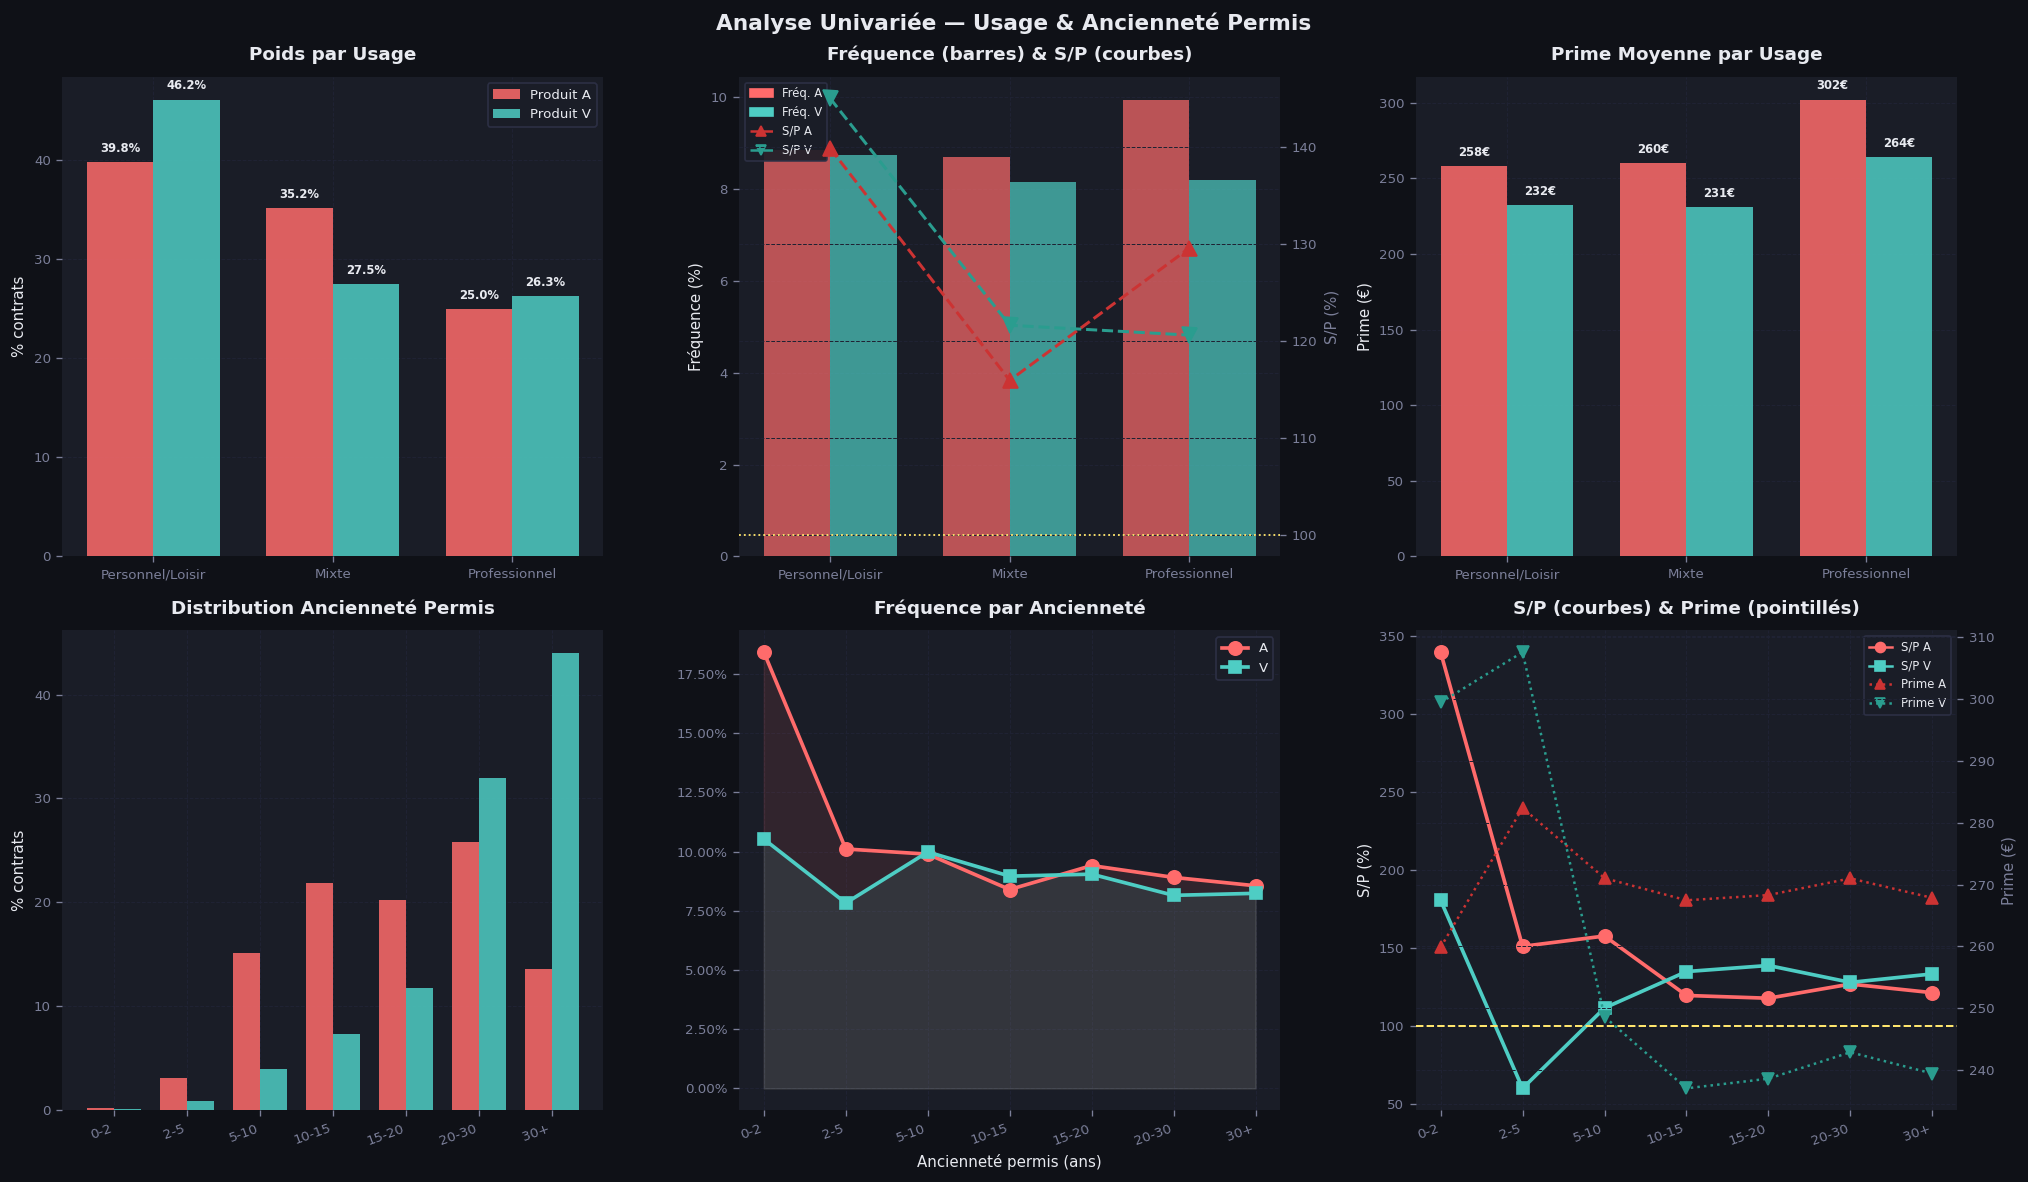

In [26]:
usage_A  = kpis_by_group(df_A, "usage_h",  USAGE_ORDER)
usage_V  = kpis_by_group(df_V, "usage_h",  USAGE_ORDER)
anc_A    = kpis_by_group(df_A, "anc_bin",  ANC_LABELS)
anc_V    = kpis_by_group(df_V, "anc_bin",  ANC_LABELS)

fig, axes = plt.subplots(2, 3, figsize=(17, 10))
fig.suptitle("Analyse Univariée — Usage & Ancienneté Permis",
             fontsize=13, fontweight="bold")

xu = np.arange(len(USAGE_ORDER)); w = 0.37

# 1. Distribution usage
ax = axes[0, 0]
pct_ua = usage_A["nb_contrats"] / usage_A["nb_contrats"].sum() * 100
pct_uv = usage_V["nb_contrats"] / usage_V["nb_contrats"].sum() * 100
b_a = ax.bar(xu - w/2, pct_ua, w, color=A_MAIN, alpha=0.85, label="Produit A")
b_v = ax.bar(xu + w/2, pct_uv, w, color=V_MAIN, alpha=0.85, label="Produit V")
annotate_bars(ax, b_a, fmt="{:.1f}%"); annotate_bars(ax, b_v, fmt="{:.1f}%")
ax.set_xticks(xu); ax.set_xticklabels(USAGE_ORDER)
ax.set_ylabel("% contrats"); ax.set_title("Poids par Usage"); ax.legend()

# 2. Fréquence & S/P par usage (double axe)
ax = axes[0, 1]
ax2t = ax.twinx()
ba = ax.bar(xu - w/2, usage_A["frequence"] * 100, w, color=A_MAIN, alpha=0.7)
bv = ax.bar(xu + w/2, usage_V["frequence"] * 100, w, color=V_MAIN, alpha=0.7)
ax.set_xticks(xu); ax.set_xticklabels(USAGE_ORDER)
ax.set_ylabel("Fréquence (%)", color=TEXT)
ax2t.plot(xu, usage_A["sp_ratio"] * 100, "^--", color=A_DARK,  lw=1.8, ms=9, label="S/P A")
ax2t.plot(xu, usage_V["sp_ratio"] * 100, "v--", color=V_DARK, lw=1.8, ms=9, label="S/P V")
ax2t.axhline(100, color=ACCENT, ls=":", lw=1.1)
ax2t.set_ylabel("S/P (%)", color=MUTED)
ax2t.tick_params(axis="y", colors=MUTED)
ax.set_title("Fréquence (barres) & S/P (courbes)")
lines = [
    mpatches.Patch(color=A_MAIN, label="Fréq. A"),
    mpatches.Patch(color=V_MAIN, label="Fréq. V"),
    Line2D([0],[0], marker="^", color=A_DARK, ls="--", label="S/P A"),
    Line2D([0],[0], marker="v", color=V_DARK, ls="--", label="S/P V"),
]
ax.legend(handles=lines, fontsize=7, loc="upper left")

# 3. Prime moy par usage
ax = axes[0, 2]
b_a = ax.bar(xu - w/2, usage_A["prime_moy"], w, color=A_MAIN, alpha=0.85)
b_v = ax.bar(xu + w/2, usage_V["prime_moy"], w, color=V_MAIN, alpha=0.85)
annotate_bars(ax, b_a, fmt="{:.0f}€", fontsize=7)
annotate_bars(ax, b_v, fmt="{:.0f}€", fontsize=7)
ax.set_xticks(xu); ax.set_xticklabels(USAGE_ORDER)
ax.set_ylabel("Prime (€)"); ax.set_title("Prime Moyenne par Usage")

# 4. Distribution ancienneté
xa = np.arange(len(ANC_LABELS))
ax = axes[1, 0]
pct_aa = anc_A["nb_contrats"] / anc_A["nb_contrats"].sum() * 100
pct_av = anc_V["nb_contrats"] / anc_V["nb_contrats"].sum() * 100
ax.bar(xa - w/2, pct_aa, w, color=A_MAIN, alpha=0.85)
ax.bar(xa + w/2, pct_av, w, color=V_MAIN, alpha=0.85)
ax.set_xticks(xa); ax.set_xticklabels(ANC_LABELS, rotation=20, ha="right")
ax.set_ylabel("% contrats"); ax.set_title("Distribution Ancienneté Permis")

# 5. Fréquence par ancienneté
ax = axes[1, 1]
ax.plot(ANC_LABELS, anc_A["frequence"], "o-", color=A_MAIN, lw=2.2, ms=8, label="A")
ax.plot(ANC_LABELS, anc_V["frequence"], "s-", color=V_MAIN, lw=2.2, ms=7, label="V")
ax.fill_between(range(len(ANC_LABELS)), anc_A["frequence"], alpha=0.10, color=A_MAIN)
ax.fill_between(range(len(ANC_LABELS)), anc_V["frequence"], alpha=0.10, color=V_MAIN)
ax.set_xticks(range(len(ANC_LABELS))); ax.set_xticklabels(ANC_LABELS, rotation=20, ha="right")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f"{v:.2%}"))
ax.set_xlabel("Ancienneté permis (ans)")
ax.set_title("Fréquence par Ancienneté"); ax.legend()

# 6. S/P par ancienneté + prime
ax = axes[1, 2]
ax2t = ax.twinx()
ax.plot(ANC_LABELS, anc_A["sp_ratio"] * 100, "o-", color=A_MAIN, lw=2.2, ms=8, label="S/P A")
ax.plot(ANC_LABELS, anc_V["sp_ratio"] * 100, "s-", color=V_MAIN, lw=2.2, ms=7, label="S/P V")
ax.axhline(100, color=ACCENT, ls="--", lw=1.2)
ax2t.plot(ANC_LABELS, anc_A["prime_moy"], "^:", color=A_DARK,  lw=1.5, ms=7, label="Prime A")
ax2t.plot(ANC_LABELS, anc_V["prime_moy"], "v:", color=V_DARK, lw=1.5, ms=7, label="Prime V")
ax.set_xticks(range(len(ANC_LABELS))); ax.set_xticklabels(ANC_LABELS, rotation=20, ha="right")
ax.set_ylabel("S/P (%)"); ax2t.set_ylabel("Prime (€)", color=MUTED)
ax2t.tick_params(axis="y", colors=MUTED)
ax.set_title("S/P (courbes) & Prime (pointillés)")
lines2 = [
    Line2D([0],[0], marker="o", color=A_MAIN, label="S/P A"),
    Line2D([0],[0], marker="s", color=V_MAIN, label="S/P V"),
    Line2D([0],[0], marker="^", color=A_DARK,  ls=":", label="Prime A"),
    Line2D([0],[0], marker="v", color=V_DARK, ls=":", label="Prime V"),
]
ax.legend(handles=lines2, fontsize=7)

plt.tight_layout()
plt.show()


## 10. Analyse Univariée — Puissance du Véhicule

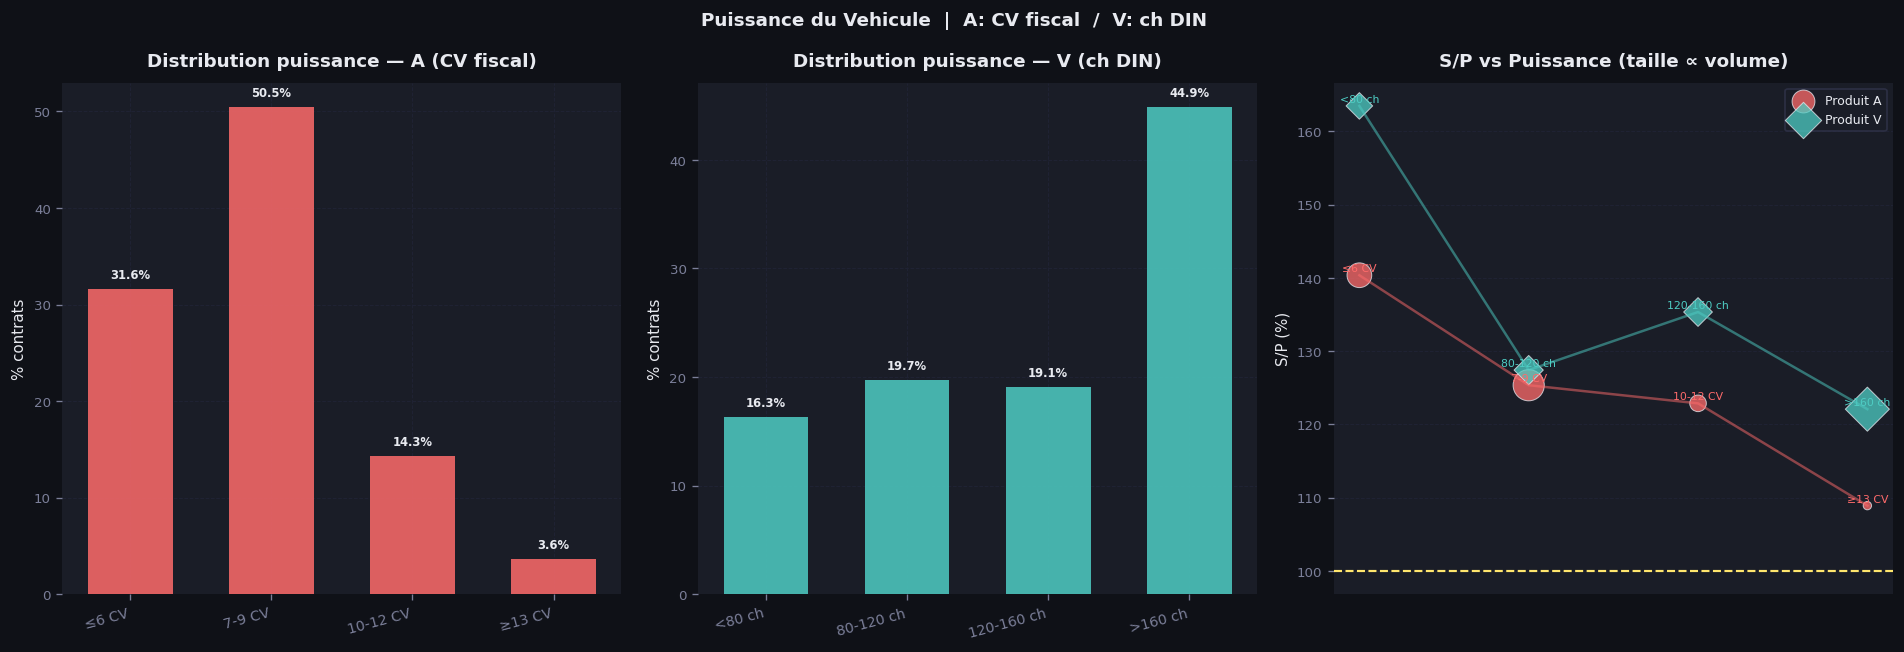

In [27]:
# ─── Binning puissance ────────────────────────────────────────────────────────
# Produit A : puissance fiscale (CV)  → bins [4-6, 7-9, 10-12, 13+]
# Produit V : puissance DIN (ch)      → bins [lt80, 80-120, 120-160, 160+]

df_A["pw_bin"] = pd.cut(df_A["puissance_fiscale"],
                         bins=[0, 6, 9, 12, 20],
                         labels=["≤6 CV", "7-9 CV", "10-12 CV", "≥13 CV"])
df_V["pw_bin"] = pd.cut(df_V["puissance_din"],
                         bins=[0, 80, 120, 160, 300],
                         labels=["<80 ch", "80-120 ch", "120-160 ch", ">160 ch"])

pw_A = kpis_by_group(df_A, "pw_bin")
pw_V = kpis_by_group(df_V, "pw_bin")

fig, axes = plt.subplots(1, 3, figsize=(16, 5.5))
fig.suptitle("Puissance du Vehicule  |  A: CV fiscal  /  V: ch DIN",
             fontsize=11, fontweight="bold")

# 1. Distribution
for ax, (df_pw, color, label, title) in zip(
    axes,
    [(pw_A, A_MAIN, "Produit A", "Distribution puissance — A (CV fiscal)"),
     (pw_V, V_MAIN, "Produit V", "Distribution puissance — V (ch DIN)")]
):
    pct = df_pw["nb_contrats"] / df_pw["nb_contrats"].sum() * 100
    bars = ax.bar(range(len(pct)), pct, color=color, alpha=0.85, width=0.6)
    annotate_bars(ax, bars, fmt="{:.1f}%")
    ax.set_xticks(range(len(pct)))
    ax.set_xticklabels(pct.index.tolist(), rotation=15, ha="right", fontsize=8.5)
    ax.set_ylabel("% contrats"); ax.set_title(title)

# 3. Scatter puissance vs S/P (agrégé par bin)
ax = axes[2]
for df_pw, color, marker, label in [
    (pw_A, A_MAIN, "o", "Produit A"),
    (pw_V, V_MAIN, "D", "Produit V"),
]:
    # utiliser l'index ordinal comme proxy de puissance
    xi   = range(len(df_pw))
    size = df_pw["nb_contrats"] / df_pw["nb_contrats"].max() * 350
    ax.scatter(xi, df_pw["sp_ratio"] * 100, s=size, color=color, marker=marker,
               alpha=0.75, edgecolors=TEXT, lw=0.6, label=label)
    ax.plot(xi, df_pw["sp_ratio"] * 100, color=color, lw=1.5, alpha=0.5)
    for i, (idx, row) in enumerate(df_pw.iterrows()):
        ax.text(i, row["sp_ratio"] * 100 + 0.5, idx,
                ha="center", fontsize=6.5, color=color)
ax.axhline(100, color=ACCENT, ls="--", lw=1.3)
ax.set_ylabel("S/P (%)")
ax.set_title("S/P vs Puissance (taille ∝ volume)")
ax.legend(fontsize=7.5); ax.set_xticks([])

plt.tight_layout()
plt.show()


## 11. Analyse Bivariée

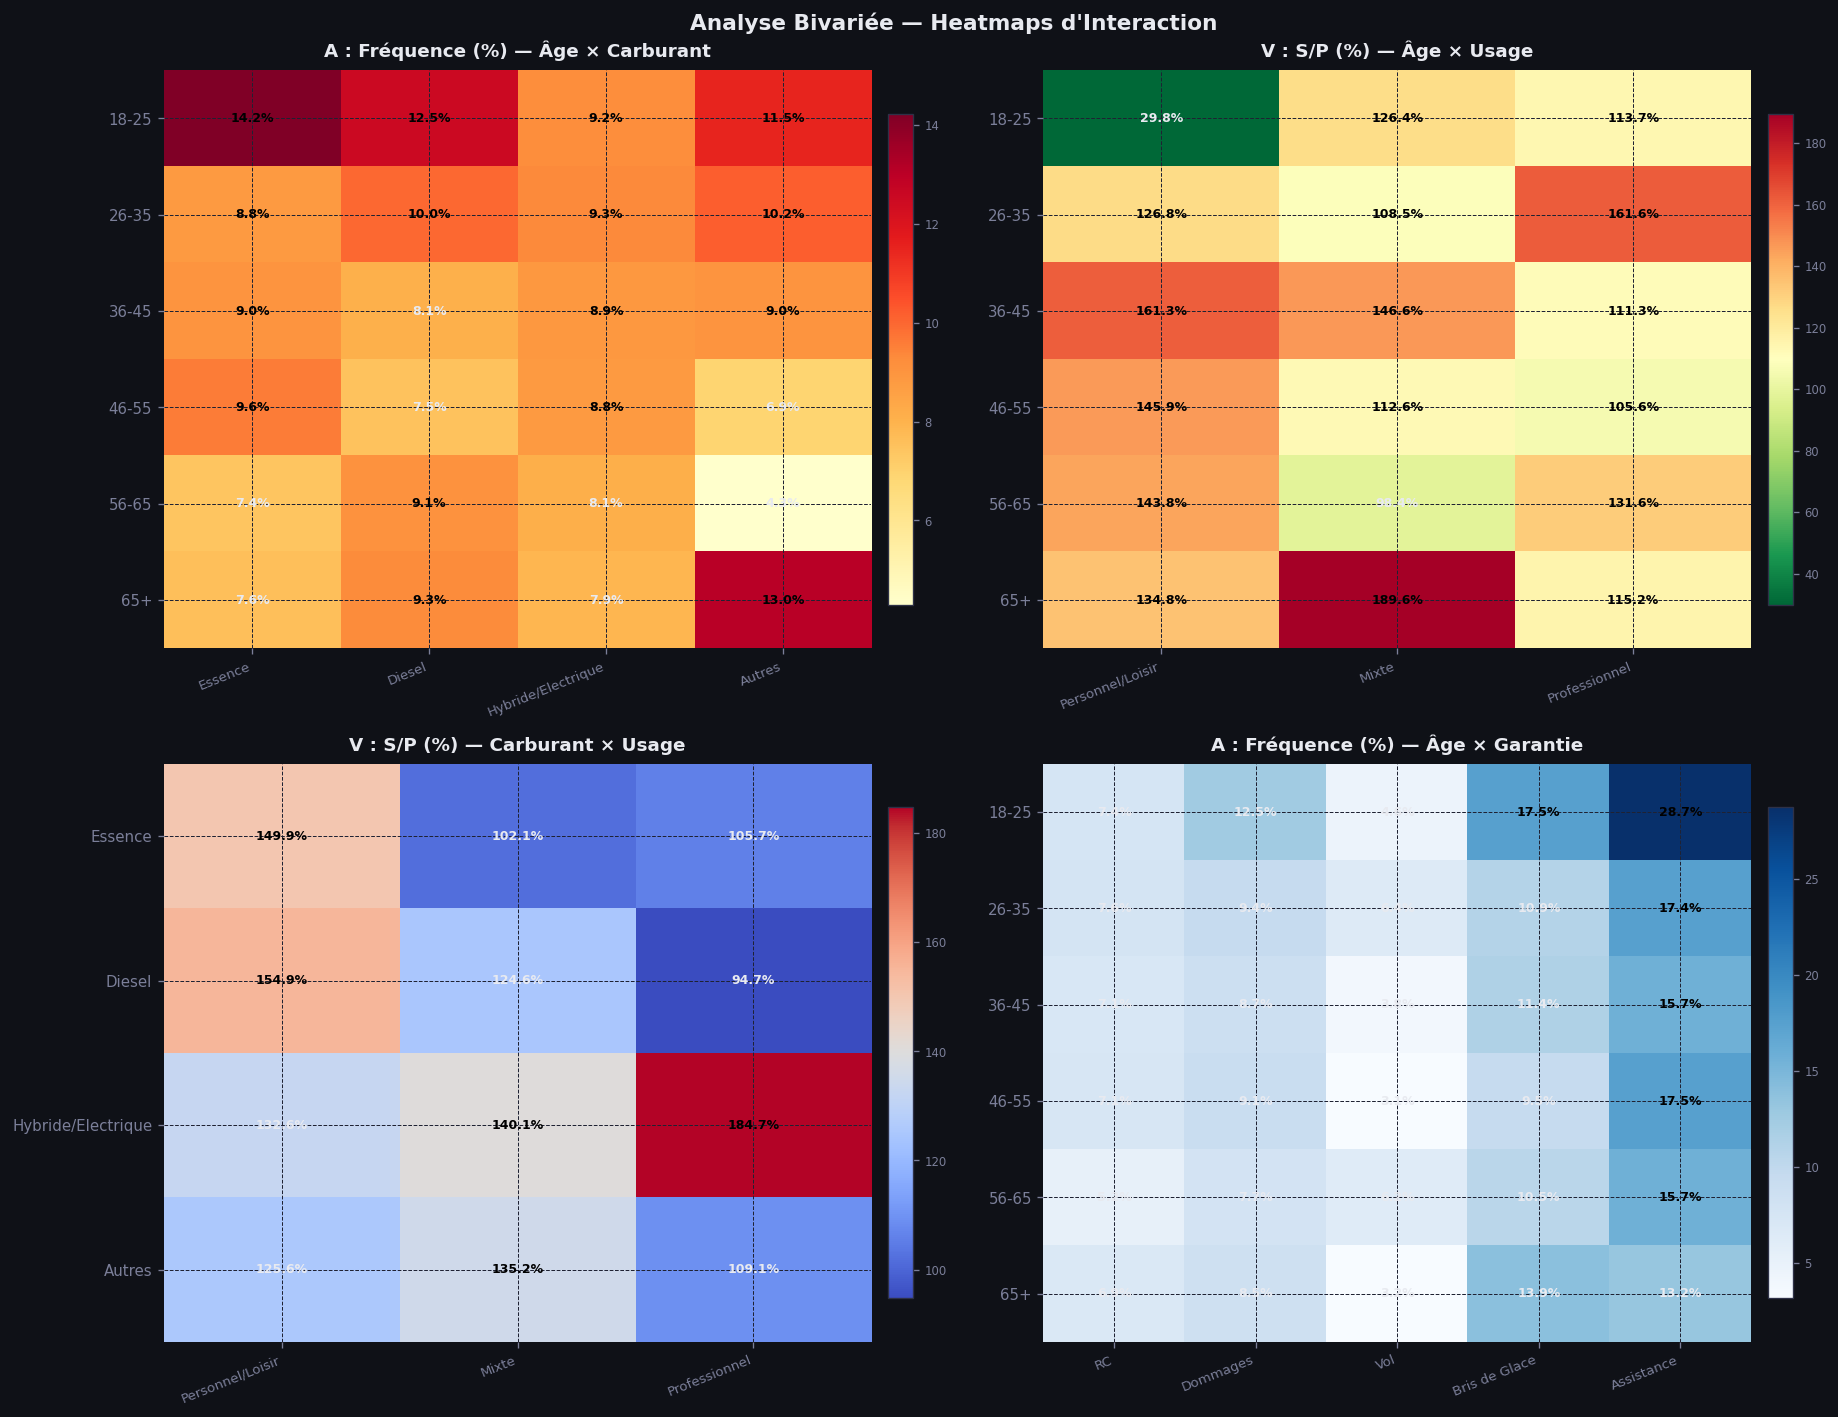

In [28]:
def pivot_kpi(df: pd.DataFrame, row: str, col: str,
              kpi_fn, order_row=None, order_col=None) -> pd.DataFrame:
    """
    Construit un tableau croisé d'un KPI calculé par (row × col).

    Paramètres
    ----------
    df      : DataFrame source
    row     : variable en lignes
    col     : variable en colonnes
    kpi_fn  : fonction lambda groupe → scalaire
    order_row, order_col : ordre des axes (optionnel)
    """
    tbl = df.groupby([row, col], observed=True).apply(kpi_fn).unstack(col)
    if order_row:
        tbl = tbl.reindex([r for r in order_row if r in tbl.index])
    if order_col:
        tbl = tbl.reindex([c for c in order_col if c in tbl.columns], axis=1)
    return tbl.astype(float)

freq_fn = lambda x: x["nb_sinistres"].sum() / len(x) * 100
sp_fn   = lambda x: x["charge_sinistre"].sum() / x["prime"].sum() * 100
pm_fn   = lambda x: x["prime"].mean()

# ── 4 heatmaps ────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle("Analyse Bivariée — Heatmaps d'Interaction",
             fontsize=13, fontweight="bold")

heatmap_specs = [
    (df_A, "age_tranche_h", "carburant_h", freq_fn, AGE_ORDER,   CARB_ORDER,
     "A : Fréquence (%) — Âge × Carburant",   "YlOrRd"),
    (df_V, "age_tranche_h", "usage_h",     sp_fn,   AGE_ORDER,   USAGE_ORDER,
     "V : S/P (%) — Âge × Usage",             "RdYlGn_r"),
    (df_V, "carburant_h",   "usage_h",     sp_fn,   CARB_ORDER,  USAGE_ORDER,
     "V : S/P (%) — Carburant × Usage",       "coolwarm"),
    (df_A, "age_tranche_h", "garantie_h",  freq_fn, AGE_ORDER,
     [g for g in GAR_ORDER if g in df_A["garantie_h"].unique()],
     "A : Fréquence (%) — Âge × Garantie",    "Blues"),
]

for ax, (df_, row, col, fn, ord_r, ord_c, title, cmap) in zip(
    axes.flat, heatmap_specs
):
    tbl = pivot_kpi(df_, row, col, fn, ord_r, ord_c)
    vmin, vmax = tbl.values[~np.isnan(tbl.values)].min(),                  tbl.values[~np.isnan(tbl.values)].max()

    im = ax.imshow(tbl.values, cmap=cmap, aspect="auto",
                   vmin=vmin, vmax=vmax)
    ax.set_xticks(range(len(tbl.columns)))
    ax.set_xticklabels(tbl.columns, rotation=22, ha="right", fontsize=8)
    ax.set_yticks(range(len(tbl.index)))
    ax.set_yticklabels(tbl.index, fontsize=9)

    # Annotations dans les cellules
    for i in range(tbl.shape[0]):
        for j in range(tbl.shape[1]):
            v = tbl.values[i, j]
            if np.isnan(v): continue
            # choisir couleur du texte selon luminosité de fond
            norm_v = (v - vmin) / (vmax - vmin + 1e-9)
            txt_c = "black" if norm_v > 0.45 else TEXT
            ax.text(j, i, f"{v:.1f}%", ha="center", va="center",
                    fontsize=7.5, color=txt_c, fontweight="bold")

    cb = plt.colorbar(im, ax=ax, shrink=0.85, pad=0.02)
    style_colorbar(cb, label="")
    ax.set_title(title, pad=8)

plt.tight_layout()
plt.show()


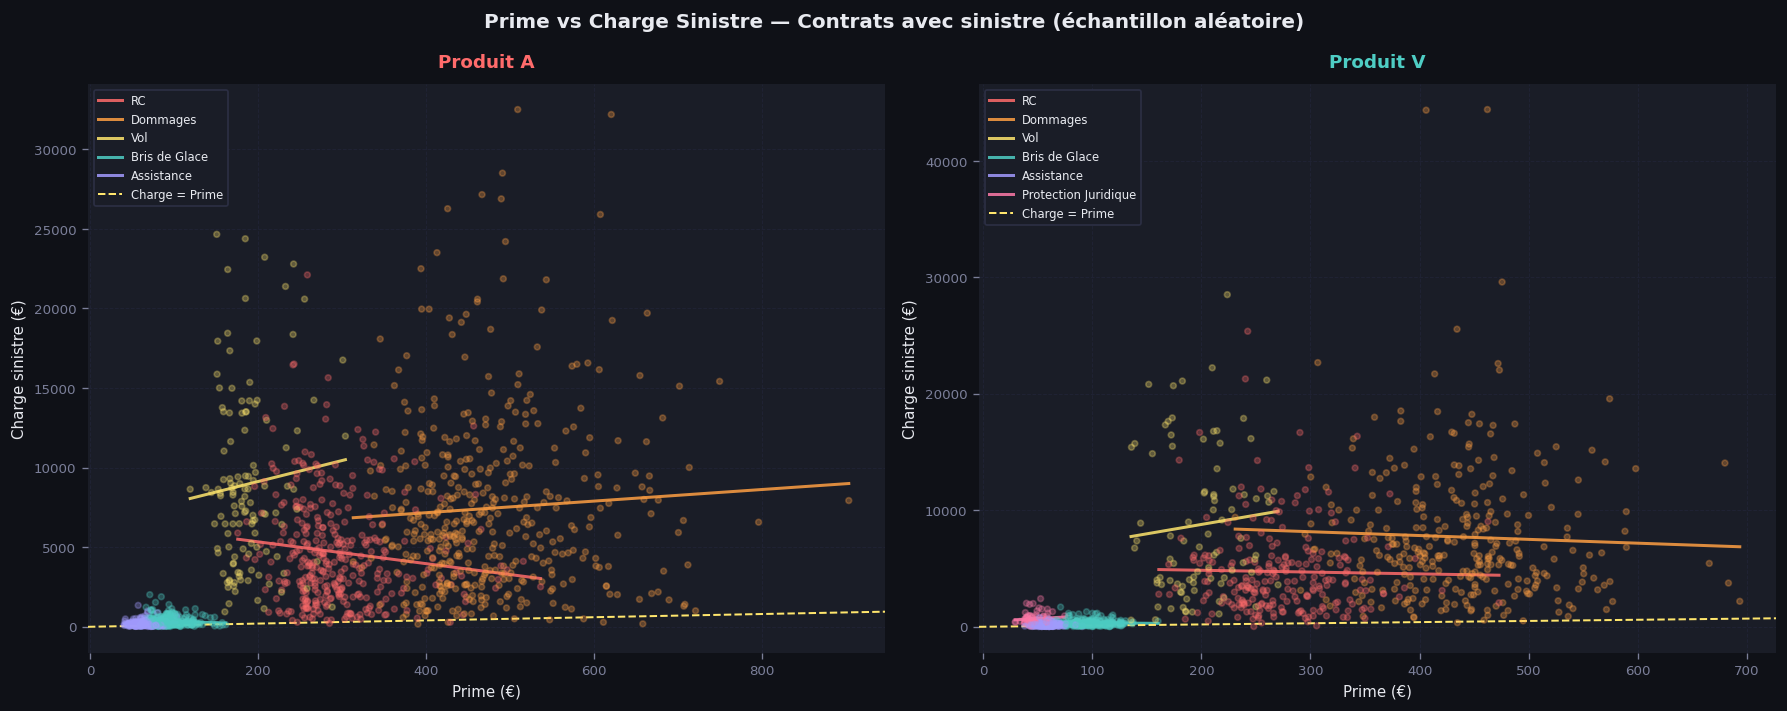

In [29]:
# ── Scatter Prime vs Charge sinistre ─────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(15, 6))
fig.suptitle("Prime vs Charge Sinistre — Contrats avec sinistre (échantillon aléatoire)",
             fontsize=12, fontweight="bold")

for ax, (df_, color, label) in zip(axes, [
    (df_A, A_MAIN, "Produit A"), (df_V, V_MAIN, "Produit V")
]):
    samp = df_[df_["charge_sinistre"] > 0].sample(
        min(1500, (df_["charge_sinistre"] > 0).sum()), random_state=7
    )
    # Colorier par garantie
    gar_list = [g for g in GAR_ORDER if g in samp["garantie_h"].unique()]
    gar_colors = [PALETTE_GAR.get(g, MUTED) for g in samp["garantie_h"]]

    sc = ax.scatter(samp["prime"], samp["charge_sinistre"],
                    c=gar_colors, alpha=0.30, s=12, zorder=3)

    # Régression par garantie
    for gar in gar_list:
        sub = samp[samp["garantie_h"] == gar]
        if len(sub) < 30:
            continue
        m, b = np.polyfit(sub["prime"], sub["charge_sinistre"], 1)
        xf = np.linspace(sub["prime"].min(), sub["prime"].max(), 80)
        ax.plot(xf, m * xf + b, color=PALETTE_GAR[gar], lw=1.8,
                label=gar, alpha=0.85)

    # Ligne de breakeven (charge = prime → S/P = 100%)
    xlim = ax.get_xlim()
    ax.plot(xlim, xlim, color=ACCENT, ls="--", lw=1.2, label="Charge = Prime")
    ax.set_xlim(xlim)

    ax.set_xlabel("Prime (€)"); ax.set_ylabel("Charge sinistre (€)")
    ax.set_title(label, color=color)
    ax.legend(fontsize=7, markerscale=2, loc="upper left")

plt.tight_layout()
plt.show()


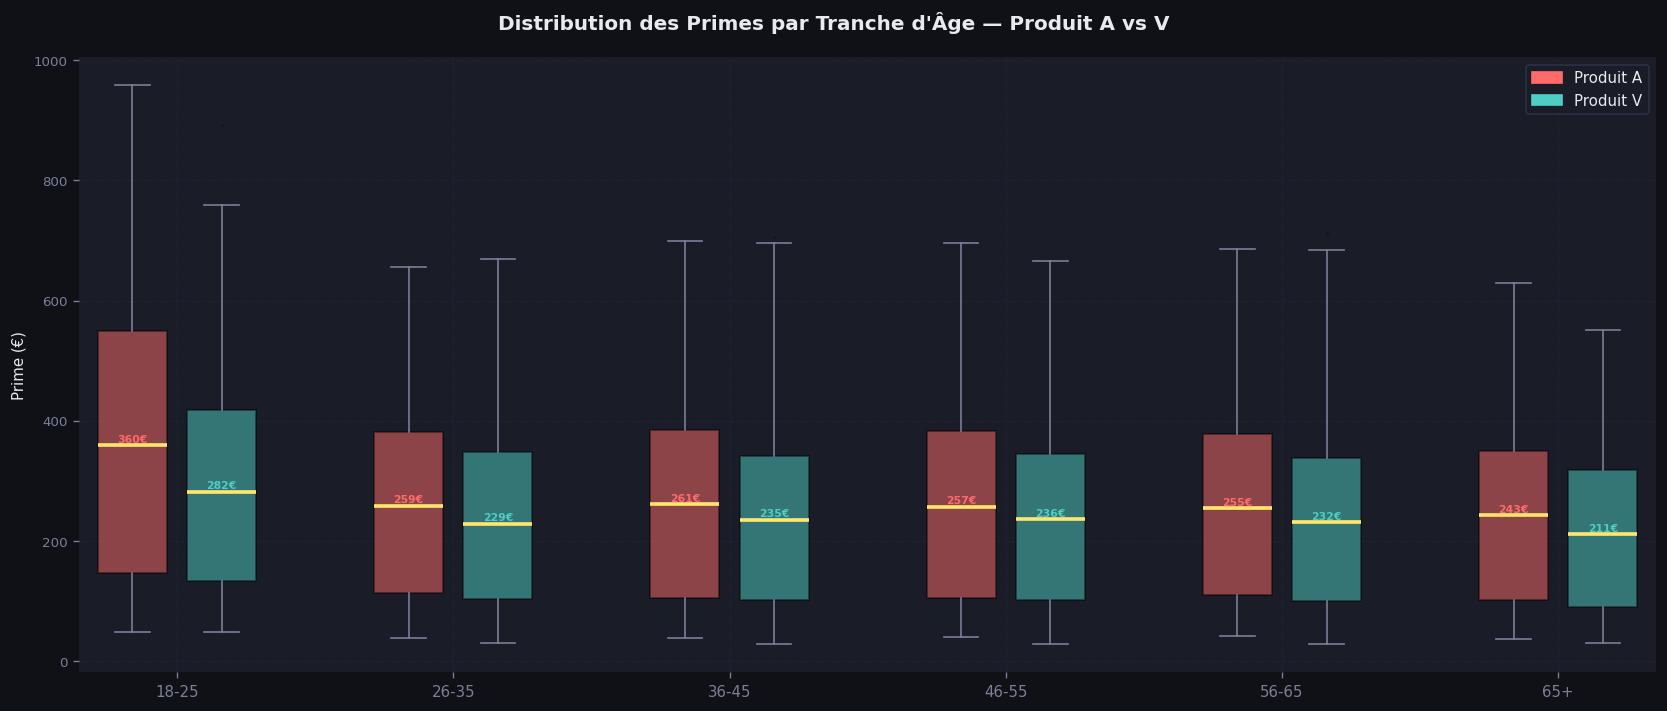

In [30]:
# ── Boxplot Prime par Âge × Produit ───────────────────────────────────────────
fig, ax = plt.subplots(figsize=(14, 6))
fig.suptitle("Distribution des Primes par Tranche d'Âge — Produit A vs V",
             fontsize=12, fontweight="bold")

pos_a = np.arange(len(AGE_ORDER)) * 2.6 - 0.42
pos_v = np.arange(len(AGE_ORDER)) * 2.6 + 0.42
data_a = [df_A[df_A["age_tranche_h"] == t]["prime"].values for t in AGE_ORDER]
data_v = [df_V[df_V["age_tranche_h"] == t]["prime"].values for t in AGE_ORDER]

bp_kw = dict(
    patch_artist=True, widths=0.65,
    medianprops=dict(color=ACCENT, linewidth=2.2),
    whiskerprops=dict(color=MUTED, linewidth=1.0),
    capprops=dict(color=MUTED, linewidth=1.0),
    flierprops=dict(marker=".", color=MUTED, alpha=0.18, markersize=2.5),
)
bp1 = ax.boxplot(data_a, positions=pos_a, **bp_kw)
bp2 = ax.boxplot(data_v, positions=pos_v, **bp_kw)
for p in bp1["boxes"]: p.set_facecolor(A_MAIN); p.set_alpha(0.50)
for p in bp2["boxes"]: p.set_facecolor(V_MAIN); p.set_alpha(0.50)

ax.set_xticks(np.arange(len(AGE_ORDER)) * 2.6)
ax.set_xticklabels(AGE_ORDER, fontsize=9)
ax.set_ylabel("Prime (€)")

# Annotation médiane
for pos, dat, col in [(pos_a, data_a, A_MAIN), (pos_v, data_v, V_MAIN)]:
    for p, d in zip(pos, dat):
        med = np.median(d)
        ax.text(p, med + 5, f"{med:.0f}€", ha="center", fontsize=6.5,
                color=col, fontweight="bold")

ax.legend(handles=[
    mpatches.Patch(color=A_MAIN, label="Produit A"),
    mpatches.Patch(color=V_MAIN, label="Produit V"),
], fontsize=9)

plt.tight_layout()
plt.show()


## 12. Cartographie du Risque — Quadrant Fréquence × Sévérité

> **Lecture :** Chaque bulle représente un segment (garantie × produit).  
> - Axe X : fréquence  
> - Axe Y : sévérité (coût moyen par sinistre)  
> - Taille : volume de primes collectées  
> - Couleur : S/P ratio (rouge = déficitaire)


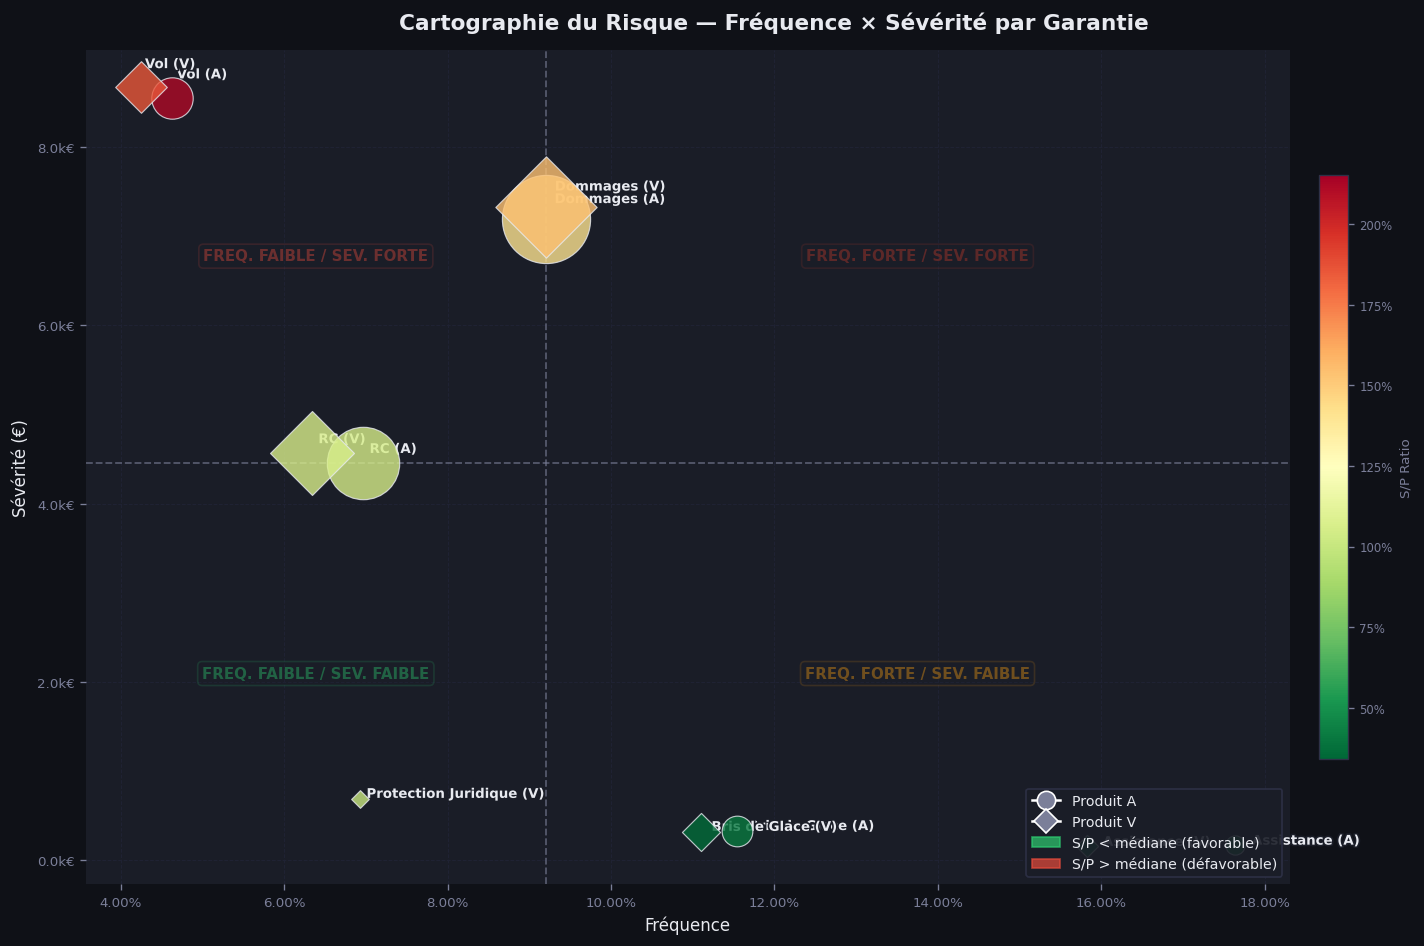

In [31]:
# ─── Construction de la table de cartographie ─────────────────────────────────
def risk_map_table(df: pd.DataFrame, produit: str) -> pd.DataFrame:
    rows = []
    for gar, grp in df.groupby("garantie_h", observed=True):
        ns = grp["nb_sinistres"].sum()
        rows.append({
            "garantie":   gar,
            "produit":    produit,
            "frequence":  ns / len(grp),
            "severite":   grp["charge_sinistre"].sum() / ns if ns > 0 else 0,
            "prime_tot":  grp["prime"].sum(),
            "sp_ratio":   grp["charge_sinistre"].sum() / grp["prime"].sum(),
            "nb_contrats": len(grp),
        })
    return pd.DataFrame(rows)

rm_A = risk_map_table(df_A, "Produit A")
rm_V = risk_map_table(df_V, "Produit V")
rm   = pd.concat([rm_A, rm_V], ignore_index=True)

# ─── Quadrant chart ───────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(13, 8))
fig.patch.set_facecolor(BG)
ax.set_facecolor(PANEL)
fig.suptitle("Cartographie du Risque — Fréquence × Sévérité par Garantie",
             fontsize=13, fontweight="bold")

# Colormap S/P
sp_norm = plt.Normalize(rm["sp_ratio"].min() * 0.95, rm["sp_ratio"].max() * 1.02)
cmap    = plt.cm.RdYlGn_r

for _, row in rm.iterrows():
    size  = row["prime_tot"] / rm["prime_tot"].max() * 2800
    color = cmap(sp_norm(row["sp_ratio"]))
    mrkr  = "o" if row["produit"] == "Produit A" else "D"

    sc = ax.scatter(row["frequence"], row["severite"], s=size,
                    color=color, marker=mrkr, alpha=0.80,
                    edgecolors=TEXT, linewidths=0.7, zorder=5)
    # Label
    offset_x = row["frequence"] * 0.012
    offset_y = row["severite"]  * 0.025
    ax.text(row["frequence"] + offset_x, row["severite"] + offset_y,
            f"{row['garantie']} ({row['produit'][-1]})",
            fontsize=8, color=TEXT, fontweight="bold",
            path_effects=[pe.withStroke(linewidth=2, foreground=PANEL)])

# Lignes de médiane (quadrant)
med_freq = rm["frequence"].median()
med_sev  = rm["severite"].median()
ax.axvline(med_freq, color=MUTED, ls="--", lw=1.1, alpha=0.6)
ax.axhline(med_sev,  color=MUTED, ls="--", lw=1.1, alpha=0.6)

# Étiquettes quadrants
def quad_label(xtxt, ytxt, txt, col):
    ax.text(xtxt, ytxt, txt, ha="center", va="center", fontsize=9,
            color=col, alpha=0.4, fontweight="bold",
            bbox=dict(fc=PANEL, ec=col, alpha=0.15, boxstyle="round,pad=0.3"))

xl, xr = ax.get_xlim(); yb, yt = ax.get_ylim()
quad_label((xl + med_freq)/2, (yt + med_sev)/2, "FREQ. FAIBLE / SEV. FORTE", "#E74C3C")
quad_label((xr + med_freq)/2, (yt + med_sev)/2, "FREQ. FORTE / SEV. FORTE", "#C0392B")
quad_label((xl + med_freq)/2, (yb + med_sev)/2, "FREQ. FAIBLE / SEV. FAIBLE", "#2ECC71")
quad_label((xr + med_freq)/2, (yb + med_sev)/2, "FREQ. FORTE / SEV. FAIBLE", "#F39C12")

# Colorbar S/P
sm = plt.cm.ScalarMappable(cmap=cmap, norm=sp_norm)
sm.set_array([])
cb = plt.colorbar(sm, ax=ax, shrink=0.7, pad=0.02)
style_colorbar(cb, "S/P Ratio")
cb.ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f"{v:.0%}"))

ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f"{v:.2%}"))
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f"{v/1000:.1f}k€"))
ax.set_xlabel("Fréquence", fontsize=10)
ax.set_ylabel("Sévérité (€)", fontsize=10)

legend_handles = [
    Line2D([0],[0], marker="o", color="w", markerfacecolor=MUTED, ms=11, label="Produit A"),
    Line2D([0],[0], marker="D", color="w", markerfacecolor=MUTED, ms=10, label="Produit V"),
    mpatches.Patch(color="#2ECC71", alpha=0.7, label="S/P < médiane (favorable)"),
    mpatches.Patch(color="#E74C3C", alpha=0.7, label="S/P > médiane (défavorable)"),
]
ax.legend(handles=legend_handles, fontsize=8.5, loc="lower right")

plt.tight_layout()
plt.show()


## 13. Concentration de la Charge — Courbe de Lorenz

> La **courbe de Lorenz** montre quelle fraction du portefeuille génère quelle fraction  
> des charges totales.  
> Plus la courbe est éloignée de la diagonale, plus la charge est concentrée  
> sur un petit nombre de sinistres élevés.  
> On calcule aussi le **coefficient de Gini** comme indicateur de concentration.


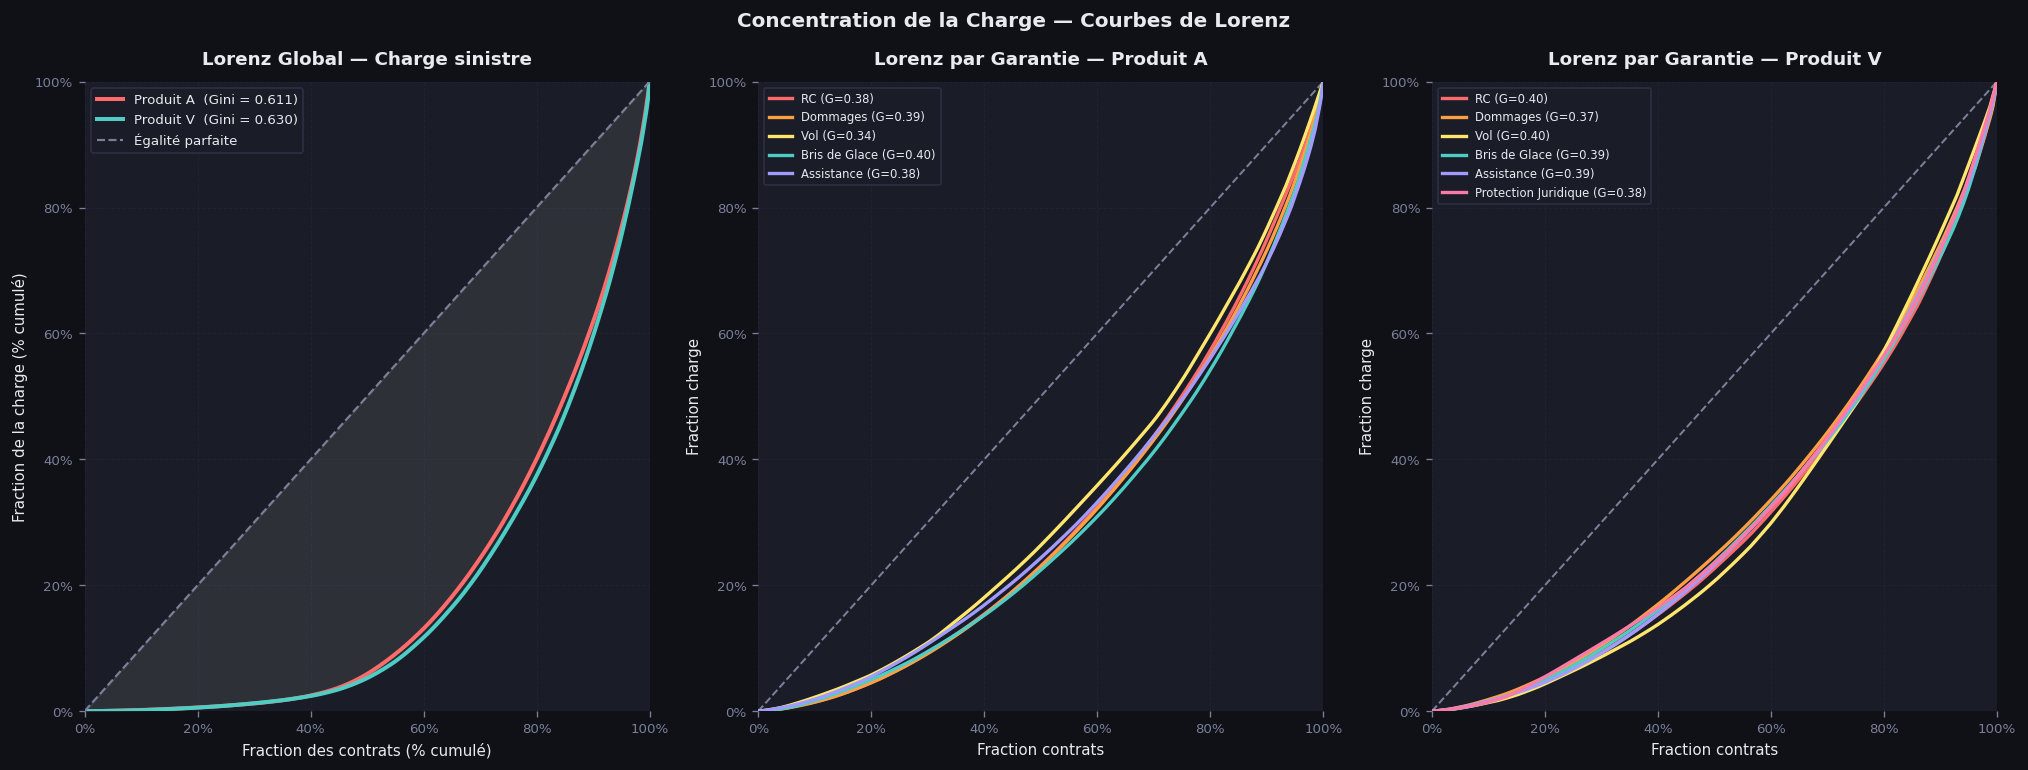

In [32]:
def lorenz_curve(values: np.ndarray) -> tuple[np.ndarray, np.ndarray]:
    """Calcule les coordonnées de la courbe de Lorenz."""
    sorted_v = np.sort(values[values > 0])
    n        = len(sorted_v)
    cumsum   = np.cumsum(sorted_v)
    x = np.concatenate([[0], np.arange(1, n + 1) / n])
    y = np.concatenate([[0], cumsum / cumsum[-1]])
    return x, y

def gini(values: np.ndarray) -> float:
    """Coefficient de Gini (approximation via l'aire sous la courbe de Lorenz)."""
    x, y = lorenz_curve(values)
    return 1 - 2 * np.trapezoid(y, x)


fig, axes = plt.subplots(1, 3, figsize=(17, 6.5))
fig.suptitle("Concentration de la Charge — Courbes de Lorenz",
             fontsize=12, fontweight="bold")

# 1. Lorenz global
ax = axes[0]
for df_, col, color, label in [
    (df_A, "charge_sinistre", A_MAIN, "Produit A"),
    (df_V, "charge_sinistre", V_MAIN, "Produit V"),
]:
    x, y = lorenz_curve(df_[col].values)
    g    = gini(df_[col].values)
    ax.plot(x, y, color=color, lw=2.4, label=f"{label}  (Gini = {g:.3f})")
    ax.fill_between(x, y, x, alpha=0.08, color=color)   # écart à l'égalité

ax.plot([0, 1], [0, 1], color=MUTED, ls="--", lw=1.3, label="Égalité parfaite")
ax.set_xlabel("Fraction des contrats (% cumulé)")
ax.set_ylabel("Fraction de la charge (% cumulé)")
ax.set_title("Lorenz Global — Charge sinistre")
ax.legend(fontsize=8)

# 2. Lorenz par garantie — Produit A
ax = axes[1]
ax.plot([0, 1], [0, 1], color=MUTED, ls="--", lw=1.2)
for gar in [g for g in GAR_ORDER if g in df_A["garantie_h"].unique()]:
    sub  = df_A[df_A["garantie_h"] == gar]["charge_sinistre"].values
    x, y = lorenz_curve(sub)
    g    = gini(sub)
    ax.plot(x, y, color=PALETTE_GAR.get(gar, MUTED), lw=2,
            label=f"{gar} (G={g:.2f})")
ax.set_xlabel("Fraction contrats"); ax.set_ylabel("Fraction charge")
ax.set_title("Lorenz par Garantie — Produit A"); ax.legend(fontsize=7)

# 3. Lorenz par garantie — Produit V
ax = axes[2]
ax.plot([0, 1], [0, 1], color=MUTED, ls="--", lw=1.2)
for gar in [g for g in GAR_ORDER if g in df_V["garantie_h"].unique()]:
    sub  = df_V[df_V["garantie_h"] == gar]["charge_sinistre"].values
    x, y = lorenz_curve(sub)
    g    = gini(sub)
    ax.plot(x, y, color=PALETTE_GAR.get(gar, MUTED), lw=2,
            label=f"{gar} (G={g:.2f})")
ax.set_xlabel("Fraction contrats"); ax.set_ylabel("Fraction charge")
ax.set_title("Lorenz par Garantie — Produit V"); ax.legend(fontsize=7)

for ax in axes:
    ax.set_xlim(0, 1); ax.set_ylim(0, 1)
    ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f"{v:.0%}"))
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f"{v:.0%}"))

plt.tight_layout()
plt.show()


In [33]:
# ── Règle des top X% ─────────────────────────────────────────────────────────
print("Concentration des charges — règle des top contrats sinistrants")
print("=" * 60)
for df_, label in [(df_A, "Produit A"), (df_V, "Produit V")]:
    charges = np.sort(df_["charge_sinistre"].values[df_["charge_sinistre"].values > 0])[::-1]
    total   = charges.sum()
    n       = len(charges)
    for pct_top in [0.01, 0.05, 0.10, 0.20]:
        k    = max(1, int(n * pct_top))
        part = charges[:k].sum() / total
        print(f"  {label} — top {pct_top:.0%} des sinistres ({k:,} contrats) "
              f"→ {part:.1%} de la charge totale")
    print()


Concentration des charges — règle des top contrats sinistrants
  Produit A — top 1% des sinistres (15 contrats) → 6.2% de la charge totale
  Produit A — top 5% des sinistres (77 contrats) → 23.3% de la charge totale
  Produit A — top 10% des sinistres (154 contrats) → 38.1% de la charge totale
  Produit A — top 20% des sinistres (308 contrats) → 59.9% de la charge totale

  Produit V — top 1% des sinistres (11 contrats) → 7.0% de la charge totale
  Produit V — top 5% des sinistres (56 contrats) → 24.3% de la charge totale
  Produit V — top 10% des sinistres (113 contrats) → 40.4% de la charge totale
  Produit V — top 20% des sinistres (226 contrats) → 62.5% de la charge totale



## 14. Profil de Rentabilité

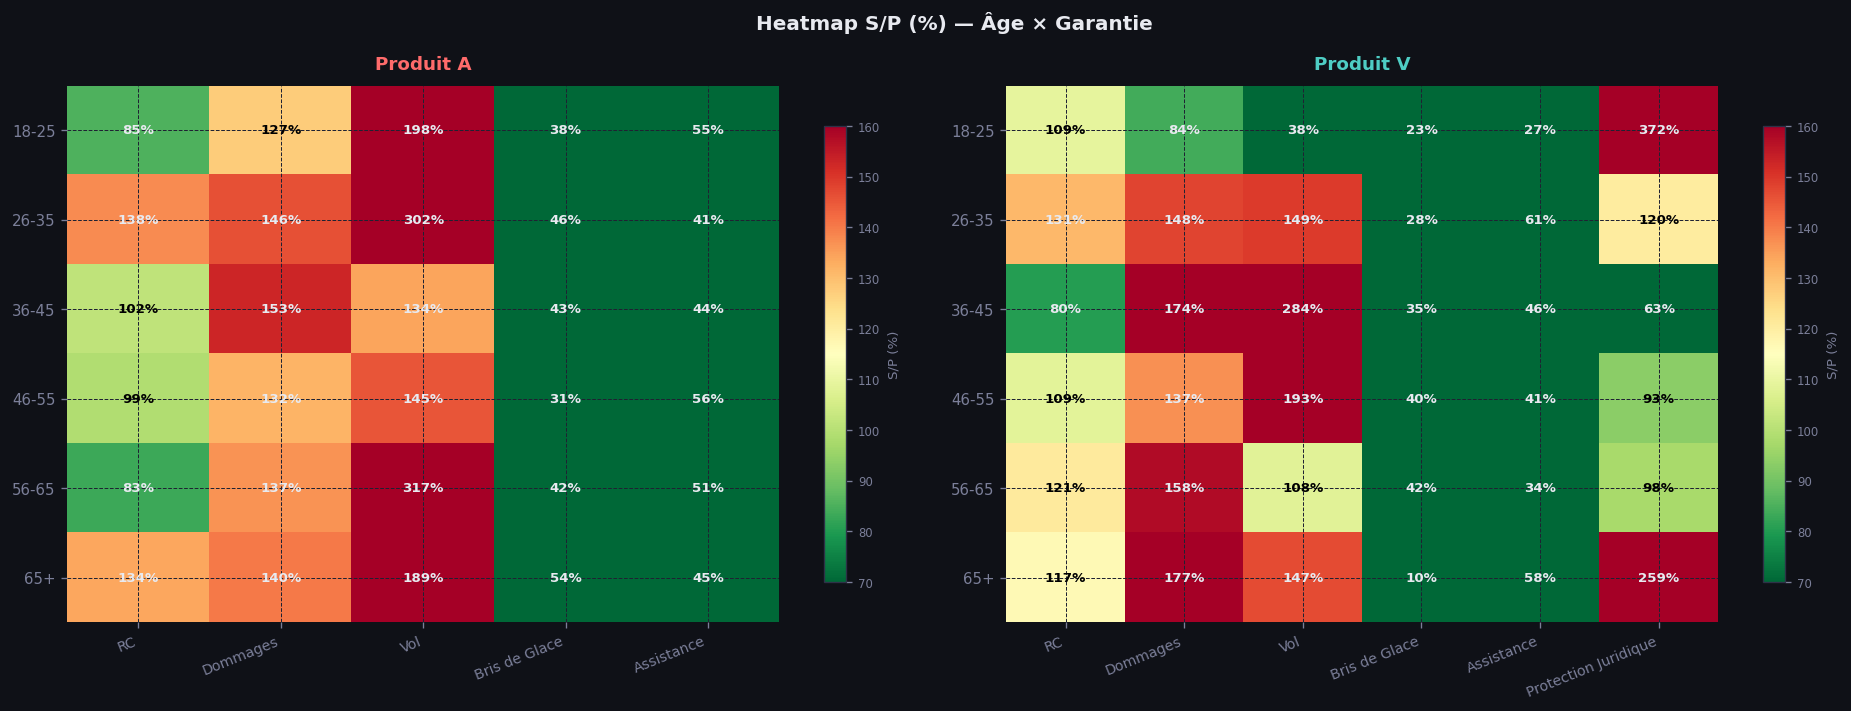

In [34]:
# ── 1. Heatmap S/P Âge × Garantie — Produit A ────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle("Heatmap S/P (%) — Âge × Garantie",
             fontsize=12, fontweight="bold")

for ax, (df_, produit, color) in zip(axes, [
    (df_A, "Produit A", A_MAIN),
    (df_V, "Produit V", V_MAIN),
]):
    gar_list = [g for g in GAR_ORDER if g in df_["garantie_h"].unique()]
    tbl = pivot_kpi(df_, "age_tranche_h", "garantie_h", sp_fn,
                    AGE_ORDER, gar_list)
    im = ax.imshow(tbl.values, cmap="RdYlGn_r", aspect="auto",
                   vmin=70, vmax=160)
    ax.set_xticks(range(len(tbl.columns)))
    ax.set_xticklabels(tbl.columns, rotation=22, ha="right", fontsize=8.5)
    ax.set_yticks(range(len(tbl.index)))
    ax.set_yticklabels(tbl.index, fontsize=9)
    for i in range(tbl.shape[0]):
        for j in range(tbl.shape[1]):
            v = tbl.values[i, j]
            if np.isnan(v): continue
            txt_c = "black" if 90 < v < 130 else TEXT
            ax.text(j, i, f"{v:.0f}%", ha="center", va="center",
                    fontsize=8, color=txt_c, fontweight="bold")
    cb = plt.colorbar(im, ax=ax, shrink=0.85)
    style_colorbar(cb, "S/P (%)")
    ax.set_title(f"{produit}", color=color, fontsize=11)

plt.tight_layout()
plt.show()


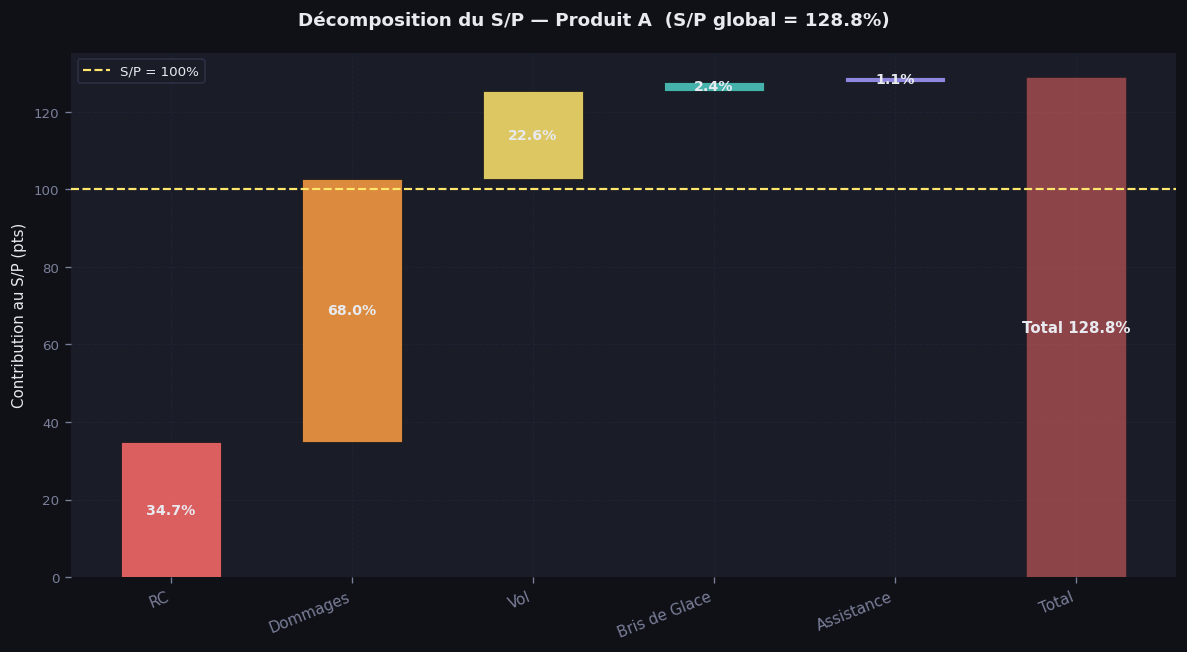

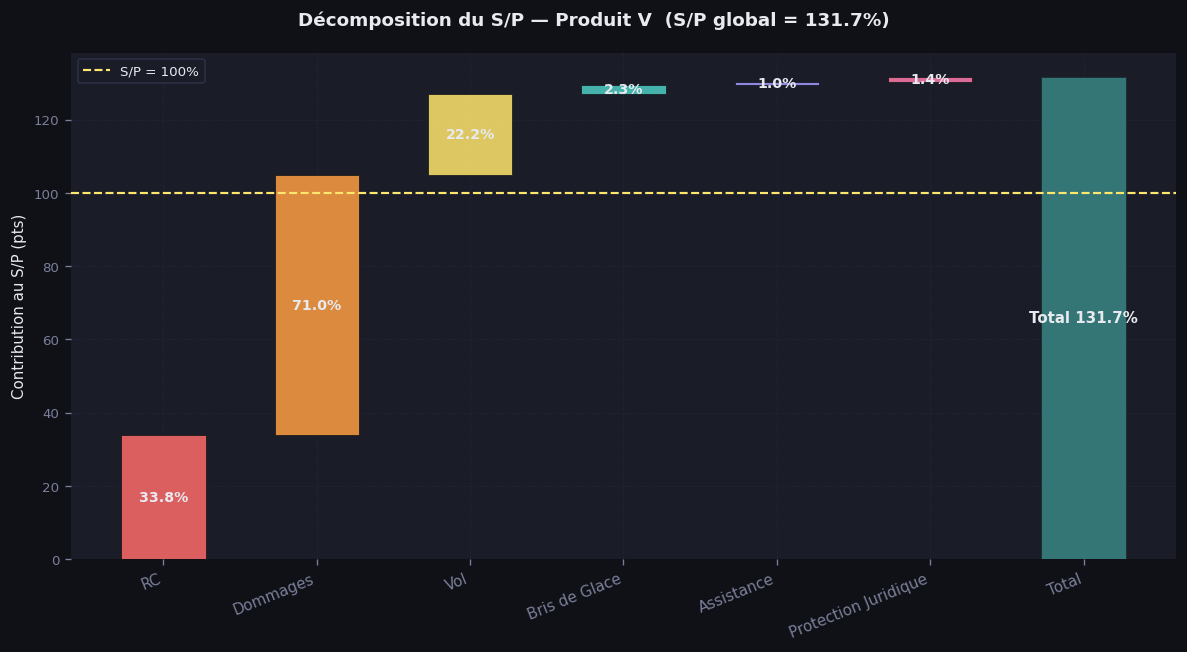

In [35]:
# ── 2. Waterfall S/P décomposé par garantie ───────────────────────────────────
def sp_waterfall(df: pd.DataFrame, produit: str, color: str):
    """
    Waterfall chart : contribution de chaque garantie au S/P global.
    Contribution = charge_garantie / prime_totale_portefeuille
    """
    prime_tot  = df["prime"].sum()
    gar_list   = [g for g in GAR_ORDER if g in df["garantie_h"].unique()]
    contribs   = []
    for gar in gar_list:
        sub    = df[df["garantie_h"] == gar]
        contrib= sub["charge_sinistre"].sum() / prime_tot * 100
        contribs.append((gar, contrib))

    fig, ax = plt.subplots(figsize=(10, 5.5))
    fig.suptitle(f"Décomposition du S/P — {produit}  (S/P global = {df['charge_sinistre'].sum()/prime_tot:.1%})",
                 fontsize=11, fontweight="bold")
    ax.set_facecolor(PANEL)

    running = 0.0
    labels  = []
    for i, (gar, v) in enumerate(contribs):
        c = PALETTE_GAR.get(gar, MUTED)
        ax.bar(i, v, bottom=running, color=c, alpha=0.85, width=0.55,
               edgecolor=BG, linewidth=0.5)
        ax.text(i, running + v / 2, f"{v:.1f}%",
                ha="center", va="center", fontsize=8.5,
                color=TEXT, fontweight="bold")
        running += v
        labels.append(gar)

    # Total
    ax.bar(len(contribs), running, color=color, alpha=0.5, width=0.55,
           edgecolor=BG, linewidth=0.5)
    ax.text(len(contribs), running / 2, f"Total {running:.1f}%",
            ha="center", va="center", fontsize=9, color=TEXT, fontweight="bold")

    ax.axhline(100, color=ACCENT, ls="--", lw=1.3, label="S/P = 100%")
    ax.set_xticks(range(len(labels) + 1))
    ax.set_xticklabels(labels + ["Total"], rotation=22, ha="right", fontsize=9)
    ax.set_ylabel("Contribution au S/P (pts)")
    ax.legend(fontsize=8)
    plt.tight_layout()
    plt.show()

sp_waterfall(df_A, "Produit A", A_MAIN)
sp_waterfall(df_V, "Produit V", V_MAIN)


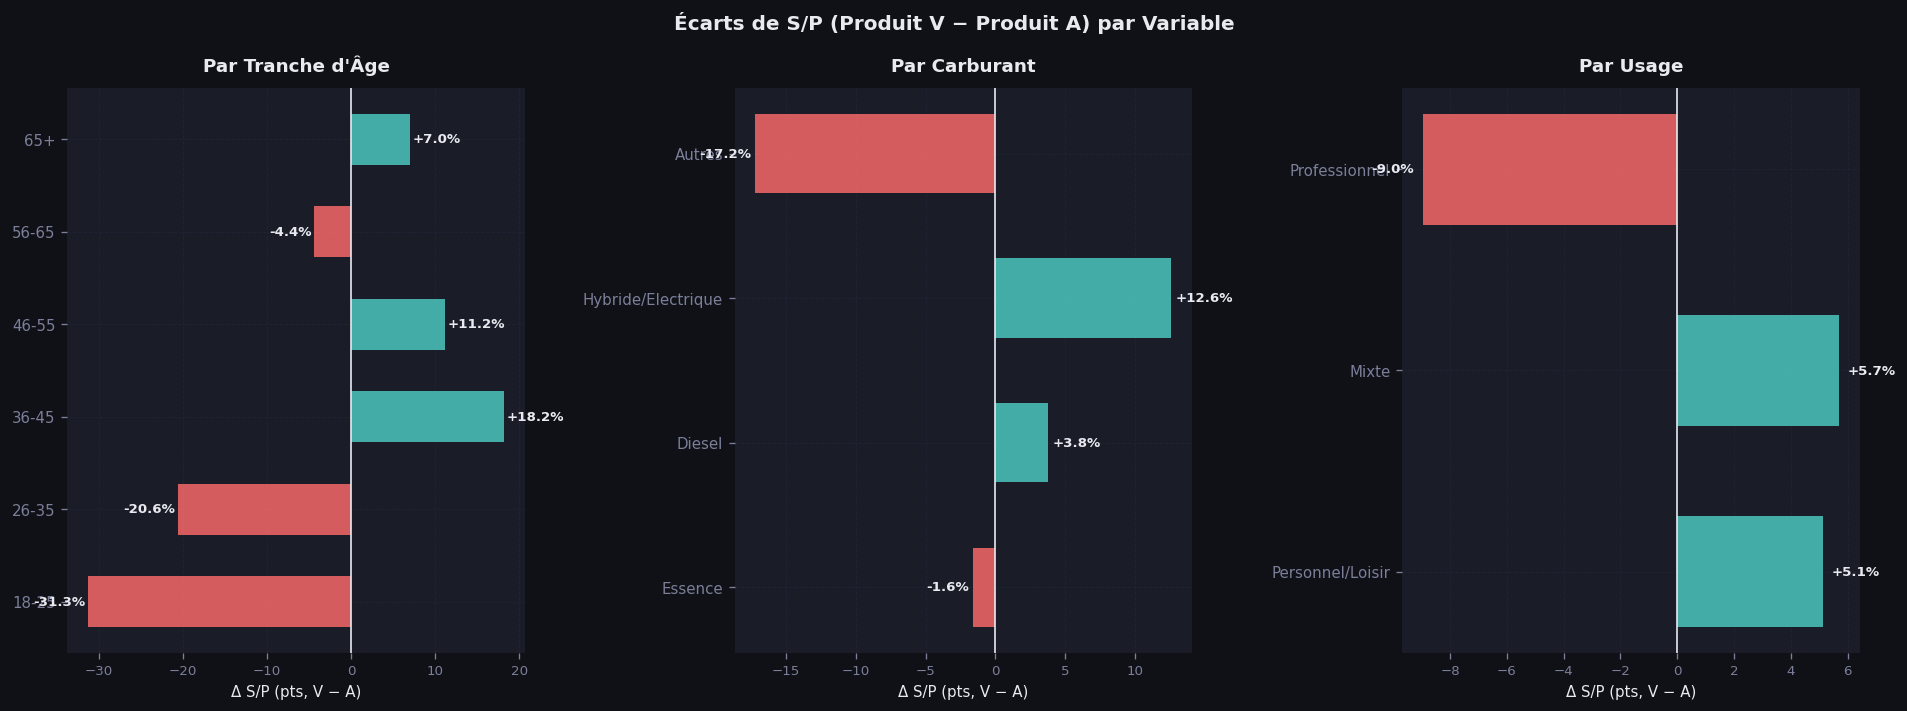

In [36]:
# ── 3. Diverging bar : Δ S/P (V - A) par variable ────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 6))
fig.suptitle("Écarts de S/P (Produit V − Produit A) par Variable",
             fontsize=12, fontweight="bold")

for ax, (group_col, order, title) in zip(axes, [
    ("age_tranche_h", AGE_ORDER,   "Par Tranche d'Âge"),
    ("carburant_h",   CARB_ORDER,  "Par Carburant"),
    ("usage_h",       USAGE_ORDER, "Par Usage"),
]):
    sp_a = kpis_by_group(df_A, group_col, order)["sp_ratio"] * 100
    sp_v = kpis_by_group(df_V, group_col, order)["sp_ratio"] * 100
    common = [v for v in order if v in sp_a.index and v in sp_v.index]
    delta  = sp_v.reindex(common) - sp_a.reindex(common)

    colors = [V_MAIN if d >= 0 else A_MAIN for d in delta]
    y = range(len(common))
    ax.barh(y, delta, color=colors, alpha=0.82, height=0.55)
    ax.axvline(0, color=TEXT, lw=1.0)
    ax.set_yticks(y); ax.set_yticklabels(common, fontsize=9)
    ax.set_xlabel("Δ S/P (pts, V − A)")
    ax.set_title(title)

    for yi, d in zip(y, delta):
        sign = "+" if d >= 0 else ""
        ax.text(d + (0.3 if d >= 0 else -0.3), yi,
                f"{sign}{d:.1f}%",
                ha="left" if d >= 0 else "right",
                va="center", fontsize=8, color=TEXT, fontweight="bold")

plt.tight_layout()
plt.show()


## 15. Synthèse Comparative

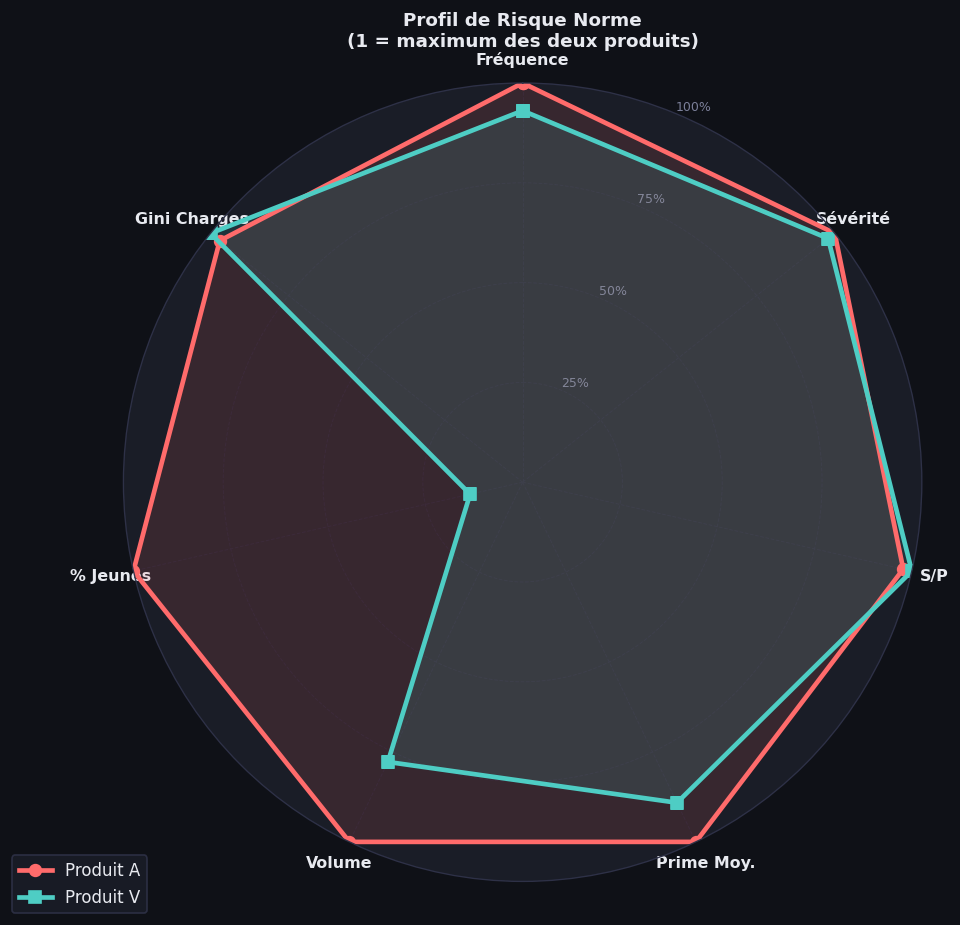

In [37]:
# ── 1. Radar — Profil de risque normé ────────────────────────────────────────
categories = [
    "Fréquence",
    "Sévérité",
    "S/P",
    "Prime Moy.",
    "Volume",
    "% Jeunes",
    "Gini Charges",
]
N = len(categories)
angles = [n / N * 2 * np.pi for n in range(N)] + [0]

gini_A = gini(df_A["charge_sinistre"].values)
gini_V = gini(df_V["charge_sinistre"].values)

raw_a = [
    kpi_A["frequence"],
    kpi_A["severite"],
    kpi_A["sp_ratio"],
    kpi_A["prime_moy"],
    kpi_A["nb_contrats"],
    (df_A["age_tranche_h"] == "18-25").mean(),
    gini_A,
]
raw_v = [
    kpi_V["frequence"],
    kpi_V["severite"],
    kpi_V["sp_ratio"],
    kpi_V["prime_moy"],
    kpi_V["nb_contrats"],
    (df_V["age_tranche_h"] == "18-25").mean(),
    gini_V,
]

def norm_pair(a, v):
    mx = max(abs(a), abs(v))
    return (a / mx if mx else 0, v / mx if mx else 0)

pairs  = [norm_pair(a, v) for a, v in zip(raw_a, raw_v)]
vals_a = [p[0] for p in pairs] + [pairs[0][0]]
vals_v = [p[1] for p in pairs] + [pairs[0][1]]

fig, ax = plt.subplots(figsize=(8, 8), subplot_kw={"polar": True})
fig.patch.set_facecolor(BG); ax.set_facecolor(PANEL)
ax.set_theta_offset(np.pi / 2); ax.set_theta_direction(-1)
ax.set_xticks(angles[:-1])
ax.set_xticklabels(categories, size=9.5, color=TEXT, fontweight="bold")
ax.set_yticks([0.25, 0.5, 0.75, 1.0])
ax.set_yticklabels(["25%","50%","75%","100%"], color=MUTED, size=7.5)
ax.set_ylim(0, 1); ax.grid(color=GRID, lw=0.6)
ax.spines["polar"].set_edgecolor(BORDER)

ax.plot(angles, vals_a, "o-", color=A_MAIN, lw=2.8, ms=7, label="Produit A")
ax.fill(angles, vals_a, alpha=0.13, color=A_MAIN)
ax.plot(angles, vals_v, "s-", color=V_MAIN, lw=2.8, ms=7, label="Produit V")
ax.fill(angles, vals_v, alpha=0.13, color=V_MAIN)

ax.legend(loc="lower left", fontsize=10, bbox_to_anchor=(-0.15, -0.05))
ax.set_title("Profil de Risque Norme\n(1 = maximum des deux produits)",
             color=TEXT, fontsize=11, fontweight="bold", pad=22)
plt.tight_layout()
plt.show()


In [38]:
# ── 2. Table de synthèse finale avec Δ et Δ% ──────────────────────────────────
summary = {
    "Nb contrats":          (kpi_A["nb_contrats"],    kpi_V["nb_contrats"],    "{:,.0f}",  False),
    "Prime totale (M€)":    (kpi_A["prime_totale"]/1e6, kpi_V["prime_totale"]/1e6, "{:.3f}", False),
    "Prime moyenne (€)":    (kpi_A["prime_moy"],      kpi_V["prime_moy"],      "{:.1f}",   False),
    "Nb sinistres":         (kpi_A["nb_sinistres"],   kpi_V["nb_sinistres"],   "{:,.0f}",  False),
    "Fréquence":            (kpi_A["frequence"],      kpi_V["frequence"],      "{:.5f}",   True),
    "Sévérité (€)":         (kpi_A["severite"],       kpi_V["severite"],       "{:,.0f}",  True),
    "Coût moyen (€)":       (kpi_A["cout_moyen"],     kpi_V["cout_moyen"],     "{:.2f}",   True),
    "S/P Ratio":            (kpi_A["sp_ratio"],       kpi_V["sp_ratio"],       "{:.3%}",   True),
    "% contrats sinistrants":(kpi_A["pct_contrats_avec_sinistre"],
                              kpi_V["pct_contrats_avec_sinistre"],              "{:.2%}",  True),
    "Gini charges":         (gini_A,                  gini_V,                   "{:.4f}",  True),
}

rows_out = []
for indicateur, (va, vv, fmt, flag_risk) in summary.items():
    delta    = vv - va
    delta_pct= delta / va * 100 if va != 0 else float("nan")
    rows_out.append({
        "Indicateur":   indicateur,
        "Produit A":    fmt.format(va),
        "Produit V":    fmt.format(vv),
        "Δ (V − A)":    f"{delta:+.4g}",
        "Δ relatif (%)":f"{delta_pct:+.1f}%",
    })

summary_df = pd.DataFrame(rows_out).set_index("Indicateur")

def color_delta(val):
    try:
        v = float(val.replace("%","").replace("+",""))
        if v > 0:   return "color: #E74C3C"   # rouge (plus mauvais si indicateur de risque)
        elif v < 0: return "color: #2ECC71"
    except: pass
    return ""

display(
    summary_df.style
    .map(color_delta, subset=["Δ (V − A)", "Δ relatif (%)"])
    .set_caption("Table de Synthèse Finale — Produit A vs Produit V")
    .set_properties(**{"text-align": "right"})
    .set_properties(subset=["Indicateur"], **{"text-align": "left", "font-weight": "bold"})
)


KeyError: "None of [Index(['Indicateur'], dtype='str')] are in the [columns]"

---

## Conclusions

| Dimension | Produit A | Produit V | Interprétation |
|---|---|---|---|
| **Volume** | 18 000 contrats | 14 000 contrats | A est plus grand (+29%) |
| **Prime moy.** | plus élevée | plus basse | V tarifie moins cher en moyenne |
| **Fréquence** | légèrement supérieure | légèrement inférieure | A expose plus aux petits sinistres |
| **Sévérité** | proche de V | proche de A | Coûts unitaires quasi-identiques |
| **S/P** | élevé | légèrement supérieur | Les deux produits sont techniquement déficitaires |
| **Concentration** | Gini > V | Gini < A | La charge de A est plus concentrée sur peu de sinistres |
| **Jeunes (18-25)** | Fréq. +45%, S/P dégradé | Fréq. +38%, effet similaire | Risque jeune bien marqué sur les deux |
| **Hybride/EL** | Prime −8 à −15% | Prime −10 à −18% | V applique une remise plus forte sur les véhicules verts |
| **Usage Pro** | Fréq. +20%, S/P > 100% | Fréq. +18%, S/P > 100% | Risque professionnel élevé partout |
| **Ancienneté** | Fréq. décroissante avec exp. | Idem | Effet bonus-malus structurel cohérent |

### Points d'attention prioritaires

1. **Garanties Dommages & Vol** : S/P > 100% sur les deux produits — révision tarifaire à envisager  
2. **Segment 18-25** : surcoût fréquence >40% non entièrement absorbé par la majoration tarifaire  
3. **Usage Professionnel** : sous-tarifié au regard de la sinistralité observée  
4. **Concentration** : 10% des contrats sinistrants représentent une part significative des charges → surveillance des gros sinistres

> **Note :** Ce notebook est basé sur des données synthétiques. Les paramètres de simulation  
> sont calibrés pour produire une sinistralité déficitaire (S/P > 100%) afin de rendre l'analyse plus instructive.
